In [3]:
import numpy as np 
import pandas as pd 
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, Normalizer, RobustScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from scipy.optimize import minimize

pd.set_option('display.max_columns', None)

pd.set_option('display.max_rows', None)

# Ignorer tous les avertissements (utilisez avec précaution)
warnings.filterwarnings("ignore")

In [2]:
# Fonction pour transformer et encoder les données
# def scale_encode(x, y=0):
#     encoder = OneHotEncoder(drop='first')
#     qualitative_vars = ['Vitesse']
#     numeric_vars = x.select_dtypes(include=['float']).columns.tolist()
#     encoded_vars = encoder.fit_transform(x[qualitative_vars]).toarray()
#     encoded_columns = encoder.get_feature_names_out(qualitative_vars)
#     encoded_df = pd.DataFrame(encoded_vars, columns=encoded_columns)
#     X = pd.concat([x.drop(['Vitesse'], axis=1), encoded_df], axis=1)
#     return X
df = pd.read_csv('Data_Modelisation-3.csv')
df2 = df[df.Vitesse == 40].copy()

df = df[df.Vitesse == 65]

# df.Vitesse = df.Vitesse.astype(str)

df = df.drop(["Vitesse"],axis = 1)
df2 = df2.drop(["Vitesse"],axis = 1)

In [6]:
1052-19

1033

In [3]:
X_o = df.drop(['Moyenne CFL F','Glissement',"hauteur (mm)"], axis=1)
X_o2 = df2.drop(['Moyenne CFL F','Glissement',"hauteur (mm)"], axis=1)

In [4]:
X_o.columns

Index(['Moyenne CFL C', 'Moyenne G% [%]', 'Fv (kg)', 'Tsurf (C)', 'T° BDR (C)',
       'Contaminant'],
      dtype='object')

In [5]:
# Neige fraiche (B)
nfb = X_o[X_o.Contaminant == 'Neige fraiche (B)'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# Neige fraiche (G)
nfg = X_o[X_o.Contaminant == 'Neige fraiche (G)'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# N.C. (G)
ncg = X_o[X_o.Contaminant == 'N.C. (G)'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# N.C. (B)
ncb = X_o[X_o.Contaminant == 'N.C. (B)'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# NC.C.
ncc = X_o[X_o.Contaminant == 'NC.C.'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# Verglas
ver = X_o[X_o.Contaminant == 'Verglas'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# Glace
gla = X_o[X_o.Contaminant == 'Glace'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# SLUSH
slh = X_o[X_o.Contaminant == 'SLUSH'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# Columns to drop in every modele


In [6]:
nfb2 = X_o2[X_o2.Contaminant == 'Neige fraiche (B)'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
nfg2 = X_o[X_o.Contaminant == 'Neige fraiche (G)'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# N.C. (G)
ncg2 = X_o2[X_o2.Contaminant == 'N.C. (G)'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# N.C. (B)
ncb2 = X_o2[X_o2.Contaminant == 'N.C. (B)'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# NC.C.
ncc2 = X_o2[X_o2.Contaminant == 'NC.C.'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# Verglas
ver2 = X_o2[X_o2.Contaminant == 'Verglas'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# Glace
gla2 = X_o2[X_o2.Contaminant == 'Glace'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# SLUSH
slh2 = X_o2[X_o2.Contaminant == 'SLUSH'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)

## Neige fraiche (B)

In [7]:
def descritisation_nfb(x):
    if x< 6:
        return "6"
    elif x< 11:
        return "11"
    elif x< 14:
        return "14"
    elif x< 16:
        return "16"
    else:
        return "more"

Meilleur point de coupure: 11.285714285714286
Paramètres: a1=0.038834524881989116, b1=0.0211895697036052, c1=-0.0009687844342058591, a2=0.17310694774154758, b2=-0.007643576768650151
R² train: 0.5198706703412015
R² test: 0.7591603195860337


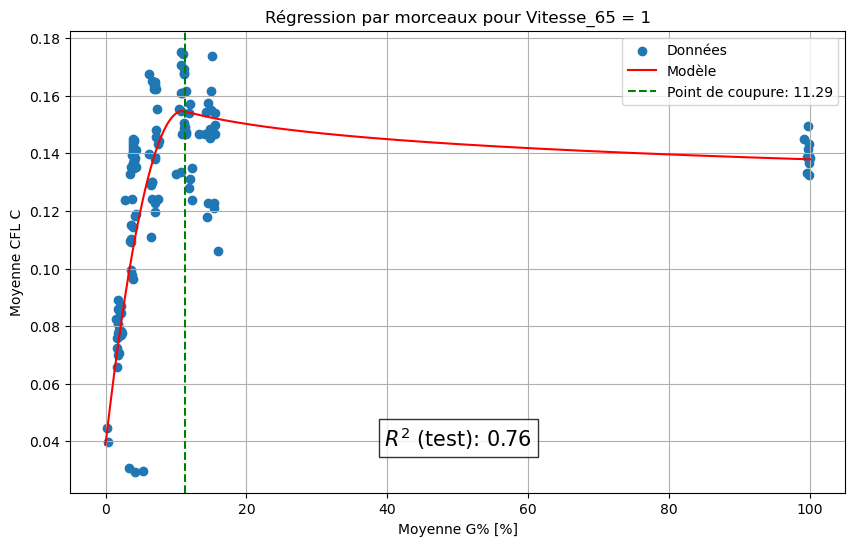

In [8]:
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2 = params
    glissement = x_k
    return (a1 + b1 * glissement + c1 * (glissement**2)) - (a2 + b2 * np.log(glissement))

# Fonction pour la contrainte de l'intercept positif
def positive_intercept_constraint(params):
    a1, b1, c1, a2, b2 = params
    return a1

# Fonction pour la contrainte de la dérivée négative
def negative_derivative_constraint(params):
    a1, b1, c1, a2, b2 = params
    return -b2

# Fonction pour la contrainte de différentiabilité
def differentiable_function_constraint(params, x_k):
    a1, b1, c1, a2, b2 = params
    glissement = x_k
    return (b1 + 2 * c1 * glissement) - (b2 / glissement)

# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1, a2, b2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 * (X['Moyenne G% [%]']**2),
                      a2 + b2 * np.log(X['Moyenne G% [%]']))
    x = np.linspace(0, x_k, 1000)
    f = lambda x: a1 + b1 * x + c1 * x**2
    y_reg = f(x)
    
    g_max_real = X['Moyenne G% [%]'].iloc[np.argmax(y)]
    g_max_pred = x[np.argmax(y_reg)]
    max_abscissa_diff = abs(g_max_real - g_max_pred)
    reg = 0.0007 * np.sum(abs(params[3:])) + 0.003 * a1
    return mean_squared_error(y, y_pred) + 0.002 * max_abscissa_diff + reg

# Données
data = nfb
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)
a = X['Moyenne G% [%]'].apply(descritisation_nfb)
X["g2"] = X['Moyenne G% [%]']**2
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=a, random_state=13)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(11, 13, 15)  # Contraindre x_k entre 11 et 12
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [0.05, 0.1, -0.001, 0.01, 0.01]
    constraints = [
        {'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)},
        {'type': 'ineq', 'fun': positive_intercept_constraint},
        {'type': 'ineq', 'fun': negative_derivative_constraint},
        {'type': 'eq', 'fun': differentiable_function_constraint, 'args': (x_k,)}
    ]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)
    if solution.success:
        a1, b1, c1, a2, b2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 * (X_train['Moyenne G% [%]']**2),
                                a2 + b2 * np.log(X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k

# Affichage des résultats
a1, b1, c1, a2, b2 = best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                       a1 + b1 * X_test['Moyenne G% [%]'] + c1 * (X_test['Moyenne G% [%]']**2),
                       a2 + b2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                     a1 + b1 * x + c1 * (x**2),
                     a2 + b2 * np.log(x))

# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k:.2f}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = 1')
plt.annotate(f'$R^2$ (test): {r2_test:.2f}', xy=(0.405, 0.1), xycoords='axes fraction', 
             fontsize=15, bbox=dict(facecolor='white', alpha=0.8))
plt.legend()
plt.grid()
plt.show()


In [9]:
a1_1=0.038834524881989116
b1_1=0.0211895697036052
c1_1=-0.0009687844342058591
a2_1=0.17310694774154758
b2_1=-0.007643576768650151

##### Vitesse 40Km/h

Meilleur point de coupure: 15.571428571428571
Paramètres: a1=0.02652826566184029, b1=0.023355230829627375, c1=-0.0008316516584229611, a2=0.2973427499470047, b2=-0.03962582825349619
R² train: 0.8652473991001628
R² test: 0.8258658235333647


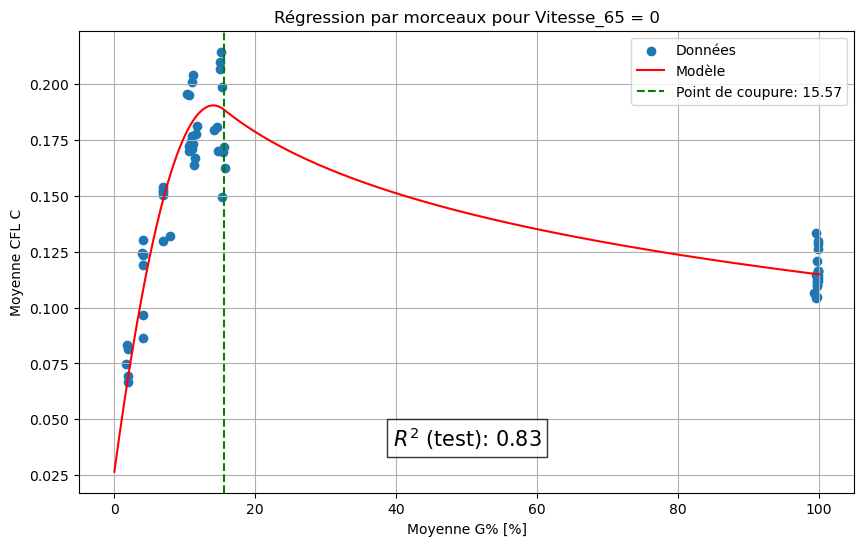

In [10]:
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1_2, b1_2, c1_2, a2_2, b2_2 = params
    glissement = x_k
    return (a1_2 + b1_2 * glissement + c1_2 * (glissement**2)) - (a2_2 + b2_2 * np.log(glissement))

# Fonction pour la contrainte de l'intercept positif
def positive_intercept_constraint(params):
    a1_2, b1_2, c1_2, a2_2, b2_2 = params
    return a1_2

# Fonction pour la contrainte de la dérivée négative
def negative_derivative_constraint(params):
    a1_2, b1_2, c1_2, a2_2, b2_2 = params
    return -b2_2

# Fonction pour la contrainte de différentiabilité
def differentiable_function_constraint(params, x_k):
    a1_2, b1_2, c1_2, a2_2, b2_2 = params
    glissement = x_k
    return (b1_2 + 2 * c1_2 * glissement) - (b2_2 / glissement)

# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1_2, b1_2, c1_2, a2_2, b2_2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1_2 + b1_2 * X['Moyenne G% [%]'] + c1_2 * (X['Moyenne G% [%]']**2),
                      a2_2 + b2_2 * np.log(X['Moyenne G% [%]']))
    x = np.linspace(0, x_k, 1000)
    f = lambda x: a1_2 + b1_2 * x + c1_2 * x**2
    y_reg = f(x)
    
    g_max_real = X['Moyenne G% [%]'].iloc[np.argmax(y)]
    g_max_pred = x[np.argmax(y_reg)]
    max_abscissa_diff = abs(g_max_real - g_max_pred)
    reg = 0 * np.sum(abs(params[3:])) + 0.003 * a1_2
    return mean_squared_error(y, y_pred) + 0 * max_abscissa_diff + reg

# Données
data = nfb2
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)
a = X['Moyenne G% [%]'].apply(descritisation_nfb)
X["g2"] = X['Moyenne G% [%]']**2
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=a, random_state=49)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k_2 = None

x_values = np.linspace(13, 16, 15)  # Contraindre x_k entre 11 et 12
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [0.05, 0.1, -0.001, 0.01, 0.01]
    constraints = [
        {'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)},
        {'type': 'ineq', 'fun': positive_intercept_constraint},
        {'type': 'ineq', 'fun': negative_derivative_constraint},
        {'type': 'eq', 'fun': differentiable_function_constraint, 'args': (x_k,)}
    ]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)
    if solution.success:
        a1_2, b1_2, c1_2, a2_2, b2_2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1_2 + b1_2 * X_train['Moyenne G% [%]'] + c1_2 * (X_train['Moyenne G% [%]']**2),
                                a2_2 + b2_2 * np.log(X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k_2 = x_k

# Affichage des résultats
a1_2, b1_2, c1_2, a2_2, b2_2 = best_params
print(f"Meilleur point de coupure: {best_x_k_2}")
print(f"Paramètres: a1={a1_2}, b1={b1_2}, c1={c1_2}, a2={a2_2}, b2={b2_2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k_2
y_pred_test = np.where(mask_test,
                       a1_2 + b1_2 * X_test['Moyenne G% [%]'] + c1_2 * (X_test['Moyenne G% [%]']**2),
                       a2_2 + b2_2 * np.log(X_test['Moyenne G% [%]']))
r2_test_2 = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test_2}")

x = np.linspace(0, 100, 1000)
y_pred_v1 = np.where(x <= best_x_k_2,
                     a1_2 + b1_2 * x + c1_2 * (x**2),
                     a2_2 + b2_2 * np.log(x))

# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k_2, color='green', linestyle='--', label=f'Point de coupure: {best_x_k_2:.2f}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = 0')
plt.annotate(f'$R^2$ (test): {r2_test_2:.2f}', xy=(0.405, 0.1), xycoords='axes fraction', 
             fontsize=15, bbox=dict(facecolor='white', alpha=0.8))
plt.legend()
plt.grid()
plt.show()


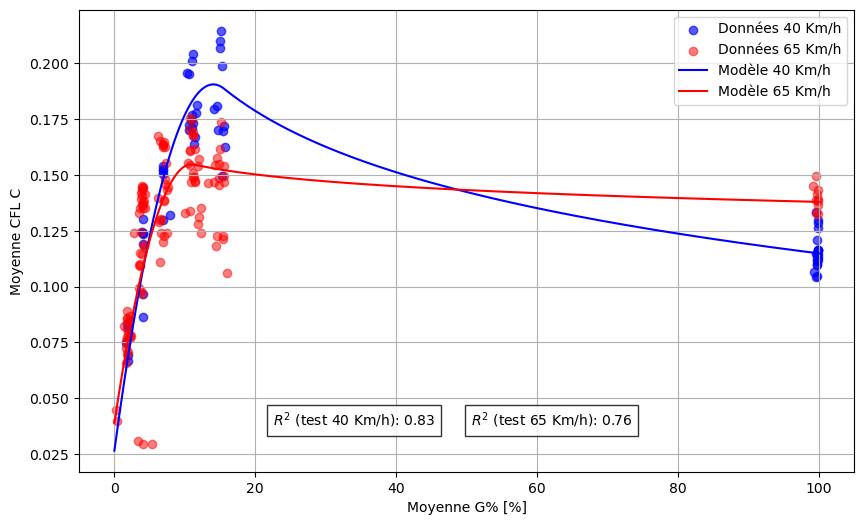

In [11]:
x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v2 = np.where(x <= best_x_k_2,
                     a1_2 + b1_2 * x + c1_2 * (x**2),
                     a2_2 + b2_2 * np.log(x))
y_pred_v1 = np.where(x <= best_x_k,
                     a1 + b1 * x + c1 * (x**2),
                     a2 + b2 * np.log(x))
# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(nfb2['Moyenne G% [%]'], nfb2['Moyenne CFL C'], label='Données 40 Km/h', alpha = 0.65, color = "b")
plt.scatter(nfb['Moyenne G% [%]'], nfb['Moyenne CFL C'], label='Données 65 Km/h', color = "red" ,alpha = 0.5)

plt.plot(x, y_pred_v2, color='b', label='Modèle 40 Km/h')
plt.plot(x, y_pred_v1, color='r', label='Modèle 65 Km/h')



plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
#plt.title(f'Régression par morceaux pour Vitesse_65 = 1')
plt.annotate(f'$R^2$ (test 65 Km/h): {r2_test:.2f}', xy=(0.505, 0.1), xycoords='axes fraction', 
             fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
plt.annotate(f'$R^2$ (test 40 Km/h): {r2_test_2:.2f}', xy=(0.250, 0.1), xycoords='axes fraction', 
             fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
plt.legend()
plt.grid()
plt.show()


In [12]:
max(y_pred_v2)- max(y_pred_v1)


0.03579837043527112

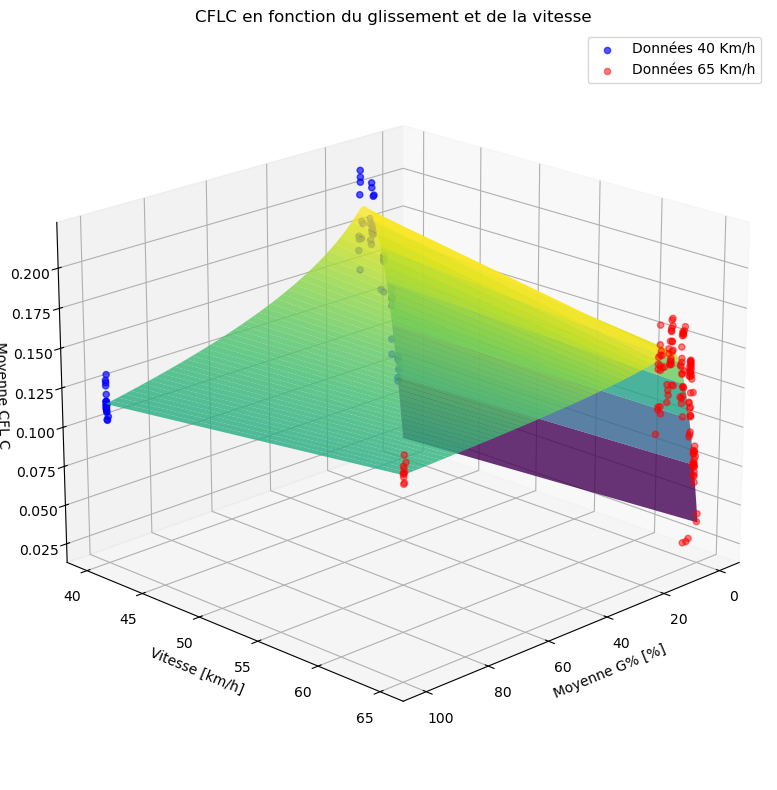

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create data points for the x-axis (Moyenne G%)
x = np.linspace(0, 100, 1000)

# Create meshgrid for 3D surface
x_mesh, y_mesh = np.meshgrid(x, [40, 65])

# Calculate predictions for both speeds
z_pred = np.zeros_like(x_mesh)

# 40 km/h predictions
z_pred[0] = np.where(x <= best_x_k_2,
                     a1_2 + b1_2 * x + c1_2 * (x**2),
                     a2_2 + b2_2 * np.log(x))

# 65 km/h predictions
z_pred[1] = np.where(x <= best_x_k,
                     a1 + b1 * x + c1 * (x**2),
                     a2 + b2 * np.log(x))

# Create the 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
surf = ax.plot_surface(x_mesh, y_mesh, z_pred, cmap='viridis', alpha=0.8)

# Plot scatter points for actual data
ax.scatter(nfb2['Moyenne G% [%]'], 
           np.full(len(nfb2), 40), 
           nfb2['Moyenne CFL C'],
           color='blue', alpha=0.65, label='Données 40 Km/h')

ax.scatter(nfb['Moyenne G% [%]'], 
           np.full(len(nfb), 65), 
           nfb['Moyenne CFL C'],
           color='red', alpha=0.5, label='Données 65 Km/h')

# Set labels and title
ax.set_xlabel('Moyenne G% [%]')
ax.set_ylabel('Vitesse [km/h]')
ax.set_zlabel('Moyenne CFL C')
ax.set_title('CFLC en fonction du glissement et de la vitesse')

# Add legend
ax.legend()

# Adjust the viewing angle
ax.view_init(elev=20, azim=45)

plt.tight_layout()
plt.show()

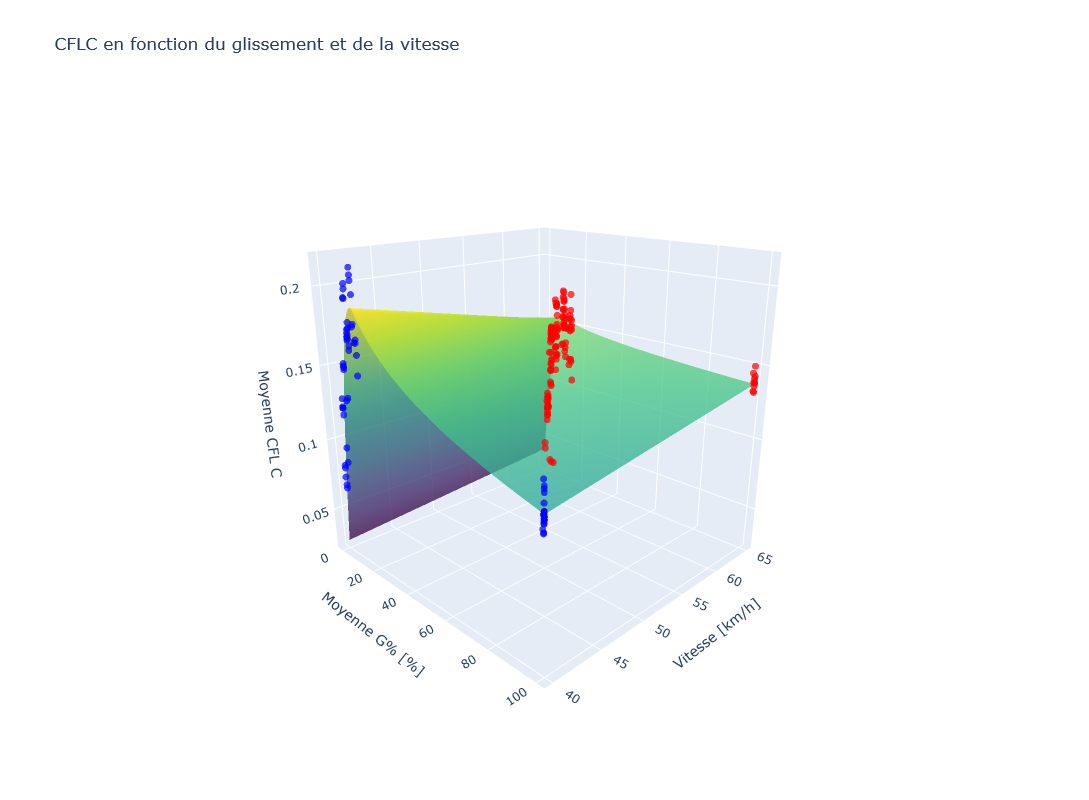

In [14]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

# Create data points for the x-axis (Moyenne G%) and y-axis (vitesse)
x = np.linspace(0, 100, 1000)
y = np.array([40, 65])

# Create a meshgrid for the 3D surface
x_mesh, y_mesh = np.meshgrid(x, y)

# Calculate predictions for the surface
z_pred = np.zeros_like(x_mesh)

# For 40 km/h predictions
z_pred[0, :] = np.where(x <= best_x_k_2,
                        a1_2 + b1_2 * x + c1_2 * (x**2),
                        a2_2 + b2_2 * np.log(x))

# For 65 km/h predictions
z_pred[1, :] = np.where(x <= best_x_k,
                        a1 + b1 * x + c1 * (x**2),
                        a2 + b2 * np.log(x))

# Create the figure
fig = go.Figure()

# Add the surface for the predictions
fig.add_trace(go.Surface(z=z_pred, x=x_mesh, y=y_mesh, colorscale='Viridis', opacity=0.75, showscale=False))

# Add scatter plot for 40 km/h data
fig.add_trace(go.Scatter3d(x=nfb2['Moyenne G% [%]'], y=np.full(len(nfb2), 40), z=nfb2['Moyenne CFL C'],
                           mode='markers', marker=dict(size=4, color='blue', opacity=0.7),
                           showlegend=False))

# Add scatter plot for 65 km/h data
fig.add_trace(go.Scatter3d(x=nfb['Moyenne G% [%]'], y=np.full(len(nfb), 65), z=nfb['Moyenne CFL C'],
                           mode='markers', marker=dict(size=4, color='red', opacity=0.7),
                           showlegend=False))

# Update layout
fig.update_layout(
    title='CFLC en fonction du glissement et de la vitesse',
    scene=dict(
        xaxis_title='Moyenne G% [%]',
        yaxis_title='Vitesse [km/h]',
        zaxis_title='Moyenne CFL C',
        camera=dict(eye=dict(x=1.6, y=-1.6, z=0.8))
    ),
    width=1200,
    height=800,
    autosize=False
)

# Show the plot
fig.show()


## Neige fraiche (G)

In [15]:
def descritisation_nfg(x):
    if x<3:
        return "3"
    elif x< 6:
        return "6"
    elif x< 9:
        return "9"
    elif x< 13:
        return "13"
    elif x< 16:
        return "16"
    else:
        return "more"

Meilleur point de coupure: 11.0
Paramètres: a1=0.03335367439646018, b1=0.024144591838340935, c1=-0.0011688019807153868, a2=0.16995537364625485, b2=0.0, c2=-0.005186310192808194
R² train: 0.8355207918579421
R² test: 0.874603202817572


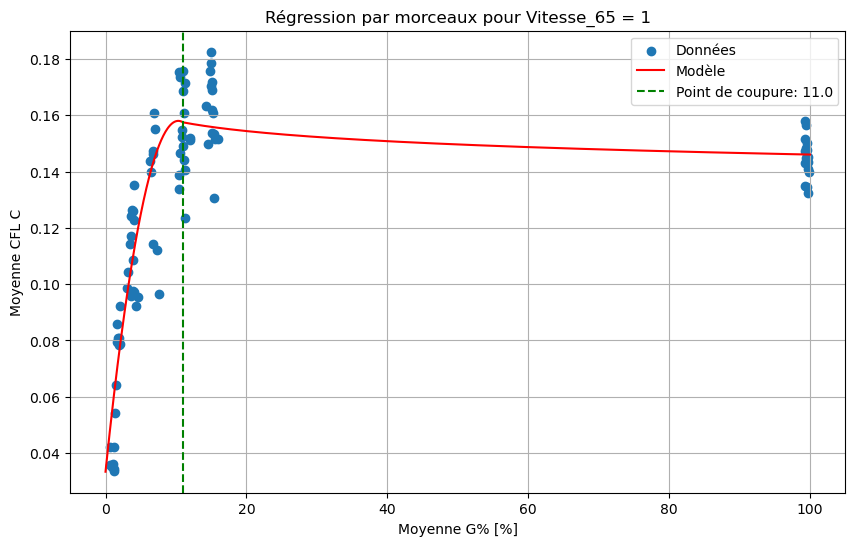

CPU times: total: 1.14 s
Wall time: 1.11 s


In [16]:
%%time
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2, c2 = params
    glissement = x_k
    return (a1 +b1 * glissement + c1 * (glissement**2) ) - (a2  + c2 * np.log(glissement))


# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1,  a2, b2, c2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 *(X['Moyenne G% [%]']**2) ,
                      a2  + c2 * np.log(X['Moyenne G% [%]']))
    
    return mean_squared_error(y, y_pred)


data = nfg
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)

a = X['Moyenne G% [%]'].apply(descritisation_nfg)
# X["g3"] = X['Moyenne G% [%]']**3
# X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]']**2
# X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  stratify = a , random_state=13)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(11,15, 10)  # Contraindre x_k entre 15 et 20
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [1, 0, 0, 1, 0, 0]
    constraints = [{'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)}]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)    
    if solution.success:
        a1, b1, c1 , a2, b2, c2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 *(X_train['Moyenne G% [%]']**2) ,
                                  a2 +  + c2 * np.log( X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k


# Affichage des résultats
a1, b1, c1, a2, b2, c2= best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}, c2={c2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                                a1 + b1 * X_test['Moyenne G% [%]'] + c1 *(X_test['Moyenne G% [%]']**2) ,
                                  a2  + c2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                    a1 +b1* x + c1 * (x**2) ,
                    a2  +c2 * np.log(x))
    
# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = {1}')
plt.legend()
plt.grid()
plt.show()

Meilleur point de coupure: 13.0
Paramètres: a1=0.02806289199292669, b1=0.021056486840946718, c1=-0.0008096276183625333, a2=0.20131714370426784, b2=-0.014170646363599665
R² train: 0.8144964153902604
R² test: 0.8239226476385557


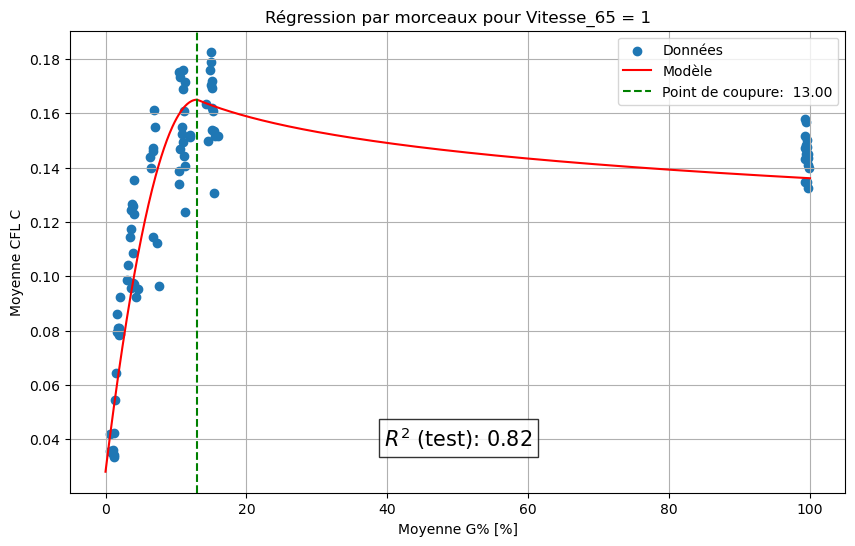

CPU times: total: 1.16 s
Wall time: 1.18 s


In [17]:
%%time
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2 = params
    glissement = x_k
    return (a1 +b1 * glissement + c1 * (glissement**2) ) - (a2  + b2 * np.log(glissement))


# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1,  a2, b2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 *(X['Moyenne G% [%]']**2) ,
                      a2  + b2 * np.log(X['Moyenne G% [%]']))
    x = np.linspace(0, x_k, 1000)
    f = lambda x: a1 + b1 * x + c1 * x**2
    y_reg = f(x)
    
    g_max_real = X['Moyenne G% [%]'].iloc[np.argmax(y)]
    g_max_pred = x[np.argmax(y_reg)]
    max_abscissa_diff = abs(g_max_real  - g_max_pred) 
    reg = 0.0003 * np.sum(abs(params[3:]))
    return mean_squared_error(y, y_pred) + 0.0005*max_abscissa_diff +reg


data = nfg
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)

a = X['Moyenne G% [%]'].apply(descritisation_nfg)
# X["g3"] = X['Moyenne G% [%]']**3
# X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]']**2
# X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  stratify = a , random_state=2)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(13,15, 10)  # Contraindre x_k entre 15 et 20
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [0.5, 0.1, -0.001, 0.4, 0.01]
    constraints = [{'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)}]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)    
    if solution.success:
        a1, b1, c1 , a2, b2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 *(X_train['Moyenne G% [%]']**2) ,
                                  a2 +  b2 * np.log( X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k


# Affichage des résultats
a1, b1, c1, a2, b2= best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                                a1 + b1 * X_test['Moyenne G% [%]'] + c1 *(X_test['Moyenne G% [%]']**2) ,
                                  a2  + b2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                    a1 +b1* x + c1 * (x**2) ,
                    a2  +b2 * np.log(x))
    
# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k: .2f}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = {1}')
plt.annotate(f'$R^2$ (test): {r2_test:.2f}', xy=(0.405, 0.1), xycoords='axes fraction', 
             fontsize=15, bbox=dict(facecolor='white', alpha=0.8))
plt.legend()
plt.grid()
plt.show()

Meilleur point de coupure: 14.0
Paramètres: a1=0.03764144571852409, b1=0.018510537741137877, c1=-0.0006810101703703983, a2=0.1839179500977835, b2=-0.007808458409313652
R² train: 0.8351903145682031
R² test: 0.8268200618051679


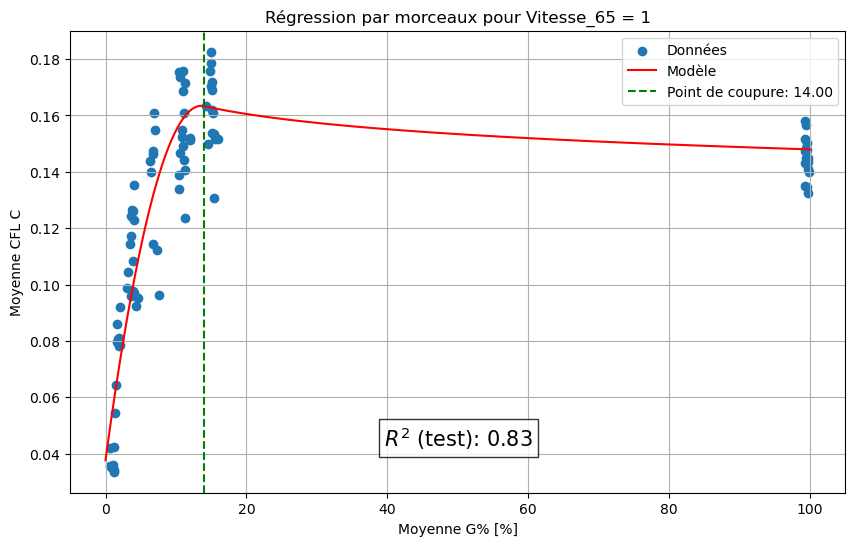

In [18]:
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2 = params
    glissement = x_k
    return (a1 + b1 * glissement + c1 * (glissement**2)) - (a2 + b2 * np.log(glissement))

# Fonction pour la contrainte de l'intercept positif
def positive_intercept_constraint(params):
    a1, b1, c1, a2, b2 = params
    return a1

# Fonction pour la contrainte de la dérivée négative
def negative_derivative_constraint(params):
    a1, b1, c1, a2, b2 = params
    return -b2

# Fonction pour la contrainte de différentiabilité
def differentiable_function_constraint(params, x_k):
    a1, b1, c1, a2, b2 = params
    glissement = x_k
    return (b1 + 2 * c1 * glissement) - (b2 / glissement)

# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1, a2, b2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 * (X['Moyenne G% [%]']**2),
                      a2 + b2 * np.log(X['Moyenne G% [%]']))
    x = np.linspace(0, x_k, 1000)
    f = lambda x: a1 + b1 * x + c1 * x**2
    y_reg = f(x)
    
    g_max_real = X['Moyenne G% [%]'].iloc[np.argmax(y)]
    g_max_pred = x[np.argmax(y_reg)]
    max_abscissa_diff = abs(g_max_real - g_max_pred)
    reg = 0.0001 * np.sum(abs(params[3:])) +0.003*a1
    return mean_squared_error(y, y_pred) + 0.0001 * max_abscissa_diff + reg

# Données
data = nfg
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)
a = X['Moyenne G% [%]'].apply(descritisation_nfg)
X["g2"] = X['Moyenne G% [%]']**2
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=a, random_state=2)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(14, 15, 15)  # Contraindre x_k entre 11 et 12
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [0.05, 0.1, -0.001, 0.01, 0.01]
    constraints = [
        {'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)},
        {'type': 'ineq', 'fun': positive_intercept_constraint},
        {'type': 'ineq', 'fun': negative_derivative_constraint},
        {'type': 'eq', 'fun': differentiable_function_constraint, 'args': (x_k,)}
    ]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)
    if solution.success:
        a1, b1, c1, a2, b2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 * (X_train['Moyenne G% [%]']**2),
                                a2 + b2 * np.log(X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k

# Affichage des résultats
a1, b1, c1, a2, b2 = best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                       a1 + b1 * X_test['Moyenne G% [%]'] + c1 * (X_test['Moyenne G% [%]']**2),
                       a2 + b2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                     a1 + b1 * x + c1 * (x**2),
                     a2 + b2 * np.log(x))

# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k:.2f}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = 1')
plt.annotate(f'$R^2$ (test): {r2_test:.2f}', xy=(0.405, 0.1), xycoords='axes fraction', 
             fontsize=15, bbox=dict(facecolor='white', alpha=0.8))
plt.legend()
plt.grid()
plt.show()


##### Vitesse 40Km/h

Meilleur point de coupure: 14.578947368421053
Paramètres: a1=0.03679148318736899, b1=0.018717855695362096, c1=-0.0006698794145362747, a2=0.19911370638412612, b2=-0.011873353659910695
R² train: 0.8315112064523761
R² test: 0.8145487409600536


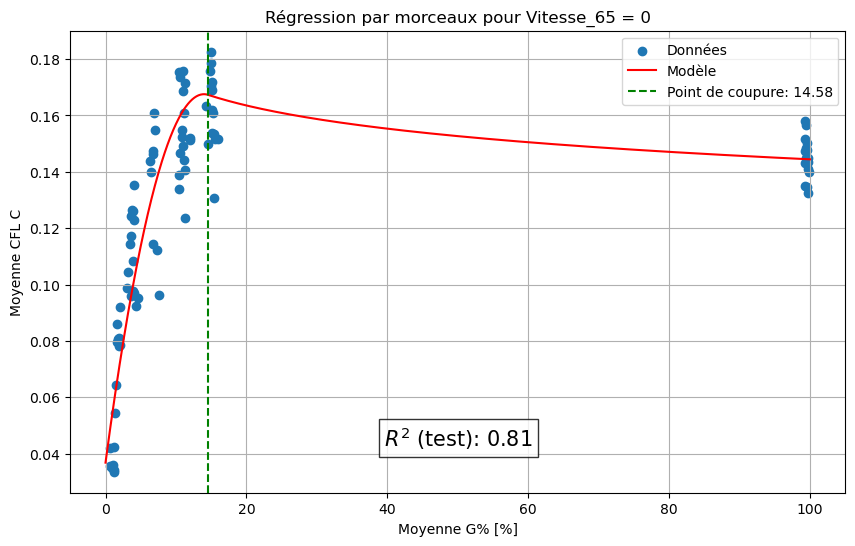

In [19]:
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1_2, b1_2, c1_2, a2_2, b2_2 = params
    glissement = x_k
    return (a1_2 + b1_2 * glissement + c1_2 * (glissement**2)) - (a2_2 + b2_2 * np.log(glissement))

# Fonction pour la contrainte de l'intercept positif
def positive_intercept_constraint(params):
    a1_2, b1_2, c1_2, a2_2, b2_2 = params
    return a1_2

# Fonction pour la contrainte de la dérivée négative
def negative_derivative_constraint(params):
    a1_2, b1_2, c1_2, a2_2, b2_2 = params
    return -b2_2

# Fonction pour la contrainte de différentiabilité
def differentiable_function_constraint(params, x_k):
    a1_2, b1_2, c1_2, a2_2, b2_2 = params
    glissement = x_k
    return (b1_2 + 2 * c1_2 * glissement) - (b2_2 / glissement)

# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1_2, b1_2, c1_2, a2_2, b2_2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1_2 + b1_2 * X['Moyenne G% [%]'] + c1_2 * (X['Moyenne G% [%]']**2),
                      a2_2 + b2_2 * np.log(X['Moyenne G% [%]']))
    x = np.linspace(0, x_k, 1000)
    f = lambda x: a1_2 + b1_2 * x + c1_2 * x**2
    y_reg = f(x)
    
    g_max_real = X['Moyenne G% [%]'].iloc[np.argmax(y)]
    g_max_pred = x[np.argmax(y_reg)]
    max_abscissa_diff = abs(g_max_real - g_max_pred)
    reg = 0 * np.sum(abs(params[3:])) + 0.003 * a1_2
    return mean_squared_error(y, y_pred) + 0 * max_abscissa_diff + reg

data = nfg2
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)
a = X['Moyenne G% [%]'].apply(descritisation_nfg)
X["g2"] = X['Moyenne G% [%]']**2
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=a, random_state=2)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k_2 = None

x_values = np.linspace(14.5, 16, 20)  # Contraindre x_k entre 11 et 12
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [0.05, 0.1, -0.001, 0.01, 0.01]
    constraints = [
        {'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)},
        {'type': 'ineq', 'fun': positive_intercept_constraint},
        {'type': 'ineq', 'fun': negative_derivative_constraint},
        {'type': 'eq', 'fun': differentiable_function_constraint, 'args': (x_k,)}
    ]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)
    if solution.success:
        a1_2, b1_2, c1_2, a2_2, b2_2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1_2 + b1_2 * X_train['Moyenne G% [%]'] + c1_2 * (X_train['Moyenne G% [%]']**2),
                                a2_2 + b2_2 * np.log(X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k_2 = x_k

# Affichage des résultats
a1_2, b1_2, c1_2, a2_2, b2_2 = best_params
print(f"Meilleur point de coupure: {best_x_k_2}")
print(f"Paramètres: a1={a1_2}, b1={b1_2}, c1={c1_2}, a2={a2_2}, b2={b2_2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k_2
y_pred_test = np.where(mask_test,
                       a1_2 + b1_2 * X_test['Moyenne G% [%]'] + c1_2 * (X_test['Moyenne G% [%]']**2),
                       a2_2 + b2_2 * np.log(X_test['Moyenne G% [%]']))
r2_test_2 = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test_2}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k_2,
                     a1_2 + b1_2 * x + c1_2 * (x**2),
                     a2_2 + b2_2 * np.log(x))

# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k_2, color='green', linestyle='--', label=f'Point de coupure: {best_x_k_2:.2f}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = 0')
plt.annotate(f'$R^2$ (test): {r2_test_2:.2f}', xy=(0.405, 0.1), xycoords='axes fraction', 
             fontsize=15, bbox=dict(facecolor='white', alpha=0.8))
plt.legend()
plt.grid()
plt.show()


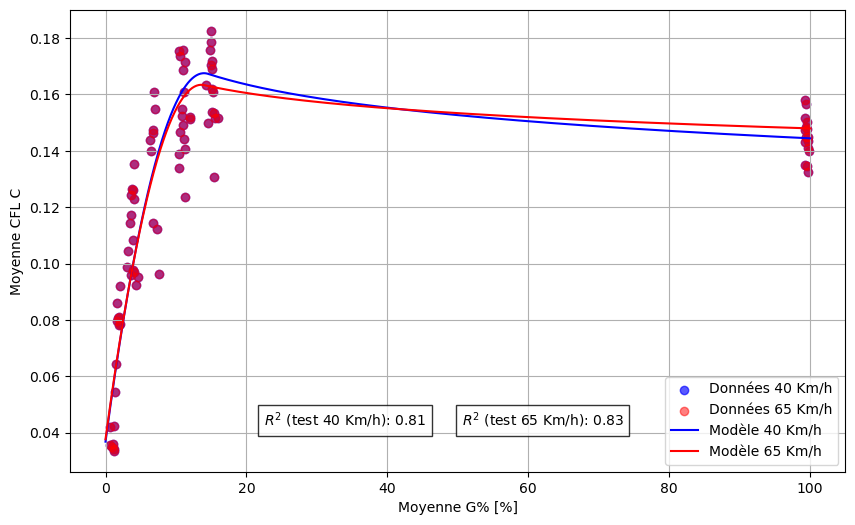

In [20]:
x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v2 = np.where(x <= best_x_k_2,
                     a1_2 + b1_2 * x + c1_2 * (x**2),
                     a2_2 + b2_2 * np.log(x))
y_pred_v1 = np.where(x <= best_x_k,
                     a1 + b1 * x + c1 * (x**2),
                     a2 + b2 * np.log(x))
# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(nfg2['Moyenne G% [%]'], nfg2['Moyenne CFL C'], label='Données 40 Km/h', alpha = 0.65, color = "b")
plt.scatter(nfg['Moyenne G% [%]'], nfg['Moyenne CFL C'], label='Données 65 Km/h', color = "red" ,alpha = 0.5)

plt.plot(x, y_pred_v2, color='b', label='Modèle 40 Km/h')
plt.plot(x, y_pred_v1, color='r', label='Modèle 65 Km/h')



plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
#plt.title(f'Régression par morceaux pour Vitesse_65 = 1')
plt.annotate(f'$R^2$ (test 65 Km/h): {r2_test:.2f}', xy=(0.505, 0.1), xycoords='axes fraction', 
             fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
plt.annotate(f'$R^2$ (test 40 Km/h): {r2_test_2:.2f}', xy=(0.250, 0.1), xycoords='axes fraction', 
             fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
plt.legend()
plt.grid()
plt.show()


In [21]:
max(y_pred_v2)- max(y_pred_v1)




0.00411960729065633

## N.C. (G)

In [22]:
def descritisation_ncg(x):
    if x<2:
        return "2"
    elif x< 5:
        return "5"
    elif x< 9:
        return "9"
    elif x< 12:
        return "12"
    elif x< 15:
        return "15"
    elif x< 17:
        return "17"
    else:
        return "more"

Meilleur point de coupure: 12.357142857142858
Paramètres: a1=0.002568608600719364, b1=0.03163156891124646, c1=-0.0013057265133770207, a2=0.21389962372505267, b2=-0.007890396605252613
R² train: 0.8228915260682802
R² test: 0.8719281415912592


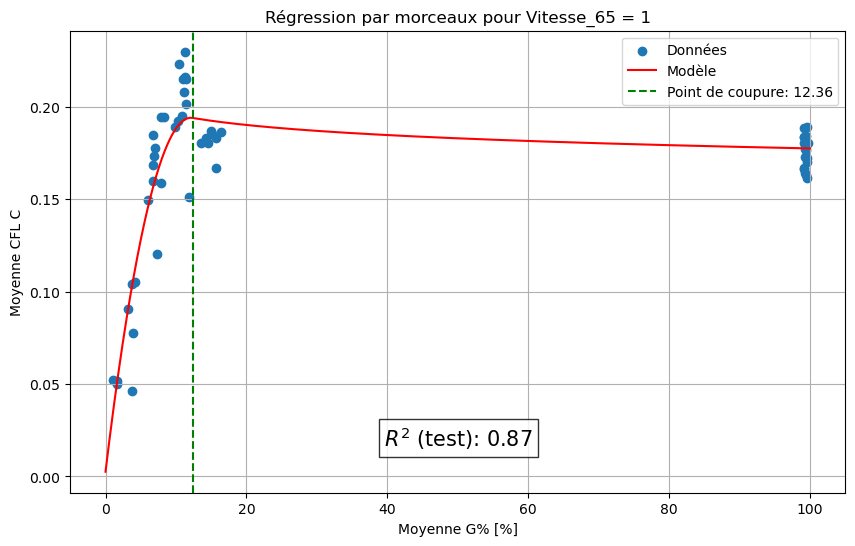

In [23]:
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2 = params
    glissement = x_k
    return (a1 + b1 * glissement + c1 * (glissement**2)) - (a2 + b2 * np.log(glissement))

# Fonction pour la contrainte de l'intercept positif
def positive_intercept_constraint(params):
    a1, b1, c1, a2, b2 = params
    return a1

# Fonction pour la contrainte de la dérivée négative
def negative_derivative_constraint(params):
    a1, b1, c1, a2, b2 = params
    return -b2

# Fonction pour la contrainte de différentiabilité
def differentiable_function_constraint(params, x_k):
    a1, b1, c1, a2, b2 = params
    glissement = x_k
    return (b1 + 2 * c1 * glissement) - (b2 / glissement)

# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1, a2, b2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 * (X['Moyenne G% [%]']**2),
                      a2 + b2 * np.log(X['Moyenne G% [%]']))
    x = np.linspace(0, x_k, 1000)
    f = lambda x: a1 + b1 * x + c1 * x**2
    y_reg = f(x)
    
    g_max_real = X['Moyenne G% [%]'].iloc[np.argmax(y)]
    g_max_pred = x[np.argmax(y_reg)]
    max_abscissa_diff = abs(g_max_real - g_max_pred)
    reg = 0.0005 * np.sum(abs(params[3:])) 
    return mean_squared_error(y, y_pred) + 0.0001 * max_abscissa_diff + reg

# Données
data = ncg
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)
a = X['Moyenne G% [%]'].apply(descritisation_ncg)
X["g2"] = X['Moyenne G% [%]']**2
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=a, random_state=60)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(10, 13, 15)  # Contraindre x_k entre 11 et 12
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [0.01, 0.1, -0.001, 0.01, 0.01]
    constraints = [
        {'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)},
        {'type': 'ineq', 'fun': positive_intercept_constraint},
        {'type': 'ineq', 'fun': negative_derivative_constraint},
        {'type': 'eq', 'fun': differentiable_function_constraint, 'args': (x_k,)}
    ]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)
    if solution.success:
        a1, b1, c1, a2, b2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 * (X_train['Moyenne G% [%]']**2),
                                a2 + b2 * np.log(X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k

# Affichage des résultats
a1, b1, c1, a2, b2 = best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                       a1 + b1 * X_test['Moyenne G% [%]'] + c1 * (X_test['Moyenne G% [%]']**2),
                       a2 + b2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                     a1 + b1 * x + c1 * (x**2),
                     a2 + b2 * np.log(x))

# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k:.2f}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = 1')
plt.annotate(f'$R^2$ (test): {r2_test:.2f}', xy=(0.405, 0.1), xycoords='axes fraction', 
             fontsize=15, bbox=dict(facecolor='white', alpha=0.8))
plt.legend()
plt.grid()
plt.show()


##### Vitesse 40Km/h

Meilleur point de coupure: 13.0
Paramètres: a1=0.0, b1=0.03874965817443574, c1=-0.0016185748190354365, a2=0.3413526764035801, b2=-0.043332732565591635
R² train: 0.9466373999338658
R² test: 0.956012002397823


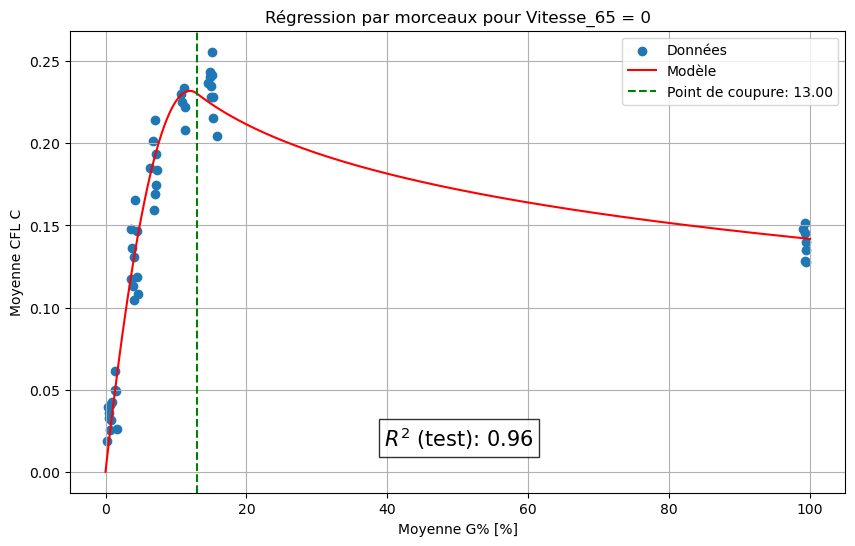

In [24]:
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1_2, b1_2, c1_2, a2_2, b2_2 = params
    glissement = x_k
    return (a1_2 + b1_2 * glissement + c1_2 * (glissement**2)) - (a2_2 + b2_2 * np.log(glissement))

# Fonction pour la contrainte de l'intercept positif
def positive_intercept_constraint(params):
    a1_2, b1_2, c1_2, a2_2, b2_2 = params
    return a1_2

# Fonction pour la contrainte de la dérivée négative
def negative_derivative_constraint(params):
    a1_2, b1_2, c1_2, a2_2, b2_2 = params
    return -b2_2

# Fonction pour la contrainte de différentiabilité
def differentiable_function_constraint(params, x_k):
    a1_2, b1_2, c1_2, a2_2, b2_2 = params
    glissement = x_k
    return (b1_2 + 2 * c1_2 * glissement) - (b2_2 / glissement)

# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1_2, b1_2, c1_2, a2_2, b2_2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1_2 + b1_2 * X['Moyenne G% [%]'] + c1_2 * (X['Moyenne G% [%]']**2),
                      a2_2 + b2_2 * np.log(X['Moyenne G% [%]']))
    x = np.linspace(0, x_k, 1000)
    f = lambda x: a1_2 + b1_2 * x + c1_2 * x**2
    y_reg = f(x)
    
    g_max_real = X['Moyenne G% [%]'].iloc[np.argmax(y)]
    g_max_pred = x[np.argmax(y_reg)]
    max_abscissa_diff = abs(g_max_real - g_max_pred)
    reg = 0 * np.sum(abs(params[3:])) + 0.003 * a1_2
    return mean_squared_error(y, y_pred) + 0 * max_abscissa_diff + reg

data = ncg2
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)
a = X['Moyenne G% [%]'].apply(descritisation_nfg)
X["g2"] = X['Moyenne G% [%]']**2
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=a, random_state=60)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k_2 = None

x_values = np.linspace(10, 13, 20)  # Contraindre x_k entre 11 et 12
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [0.05, 0.1, -0.001, 0.01, 0.01]
    constraints = [
        {'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)},
        {'type': 'ineq', 'fun': positive_intercept_constraint},
        {'type': 'ineq', 'fun': negative_derivative_constraint},
        {'type': 'eq', 'fun': differentiable_function_constraint, 'args': (x_k,)}
    ]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)
    if solution.success:
        a1_2, b1_2, c1_2, a2_2, b2_2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1_2 + b1_2 * X_train['Moyenne G% [%]'] + c1_2 * (X_train['Moyenne G% [%]']**2),
                                a2_2 + b2_2 * np.log(X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k_2 = x_k

# Affichage des résultats
a1_2, b1_2, c1_2, a2_2, b2_2 = best_params
print(f"Meilleur point de coupure: {best_x_k_2}")
print(f"Paramètres: a1={a1_2}, b1={b1_2}, c1={c1_2}, a2={a2_2}, b2={b2_2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k_2
y_pred_test = np.where(mask_test,
                       a1_2 + b1_2 * X_test['Moyenne G% [%]'] + c1_2 * (X_test['Moyenne G% [%]']**2),
                       a2_2 + b2_2 * np.log(X_test['Moyenne G% [%]']))
r2_test_2 = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test_2}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k_2,
                     a1_2 + b1_2 * x + c1_2 * (x**2),
                     a2_2 + b2_2 * np.log(x))

# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k_2, color='green', linestyle='--', label=f'Point de coupure: {best_x_k_2:.2f}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = 0')
plt.annotate(f'$R^2$ (test): {r2_test_2:.2f}', xy=(0.405, 0.1), xycoords='axes fraction', 
             fontsize=15, bbox=dict(facecolor='white', alpha=0.8))
plt.legend()
plt.grid()
plt.show()


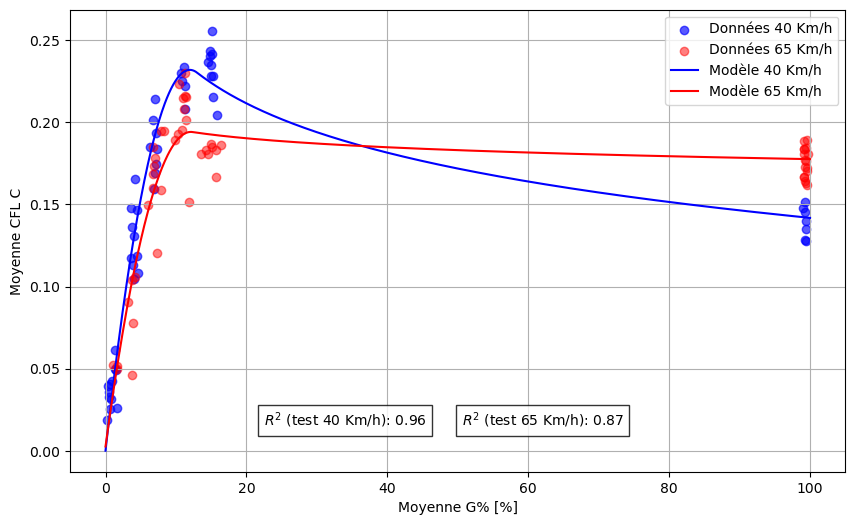

In [25]:
x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v2 = np.where(x <= best_x_k_2,
                     a1_2 + b1_2 * x + c1_2 * (x**2),
                     a2_2 + b2_2 * np.log(x))
y_pred_v1 = np.where(x <= best_x_k,
                     a1 + b1 * x + c1 * (x**2),
                     a2 + b2 * np.log(x))
# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(ncg2['Moyenne G% [%]'], ncg2['Moyenne CFL C'], label='Données 40 Km/h', alpha = 0.65, color = "b")
plt.scatter(ncg['Moyenne G% [%]'], ncg['Moyenne CFL C'], label='Données 65 Km/h', color = "red" ,alpha = 0.5)

plt.plot(x, y_pred_v2, color='b', label='Modèle 40 Km/h')
plt.plot(x, y_pred_v1, color='r', label='Modèle 65 Km/h')



plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
#plt.title(f'Régression par morceaux pour Vitesse_65 = 1')
plt.annotate(f'$R^2$ (test 65 Km/h): {r2_test:.2f}', xy=(0.505, 0.1), xycoords='axes fraction', 
             fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
plt.annotate(f'$R^2$ (test 40 Km/h): {r2_test_2:.2f}', xy=(0.250, 0.1), xycoords='axes fraction', 
             fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
plt.legend()
plt.grid()
plt.show()


In [26]:
max(y_pred_v2)- max(y_pred_v1)


0.03778035421124809

In [9]:
12*7 + 8*(73-7

612

## N.C. (B)

In [27]:
def descritisation_ncb(x):
    if x<2:
        return "2"
    elif x< 6:
        return "6"
    elif x< 9:
        return "9"
    elif x< 13:
        return "13"
    elif x< 16:
        return "16"
    else:
        return "more"

Meilleur point de coupure: 15.789473684210526
Paramètres: a1=0.03322171652908743, b1=0.024507434893803172, c1=-0.0008271964353676899, a2=0.2842989499293533, b2=-0.0254930179263048
R² train: 0.872
R² test: 0.928


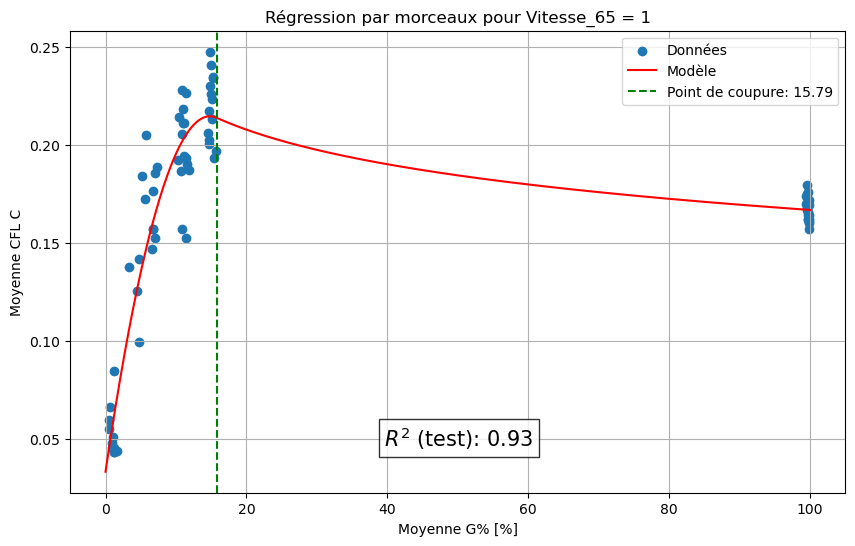

In [28]:
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2 = params
    glissement = x_k
    return (a1 + b1 * glissement + c1 * (glissement**2)) - (a2 + b2 * np.log(glissement))

# Fonction pour la contrainte de l'intercept positif
def positive_intercept_constraint(params):
    a1, b1, c1, a2, b2 = params
    return a1

# Fonction pour la contrainte de la dérivée négative
def negative_derivative_constraint(params):
    a1, b1, c1, a2, b2 = params
    return -b2

# Fonction pour la contrainte de différentiabilité
def differentiable_function_constraint(params, x_k):
    a1, b1, c1, a2, b2 = params
    glissement = x_k
    return (b1 + 2 * c1 * glissement) - (b2 / glissement)

# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1, a2, b2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 * (X['Moyenne G% [%]']**2),
                      a2 + b2 * np.log(X['Moyenne G% [%]']))
    x = np.linspace(0, x_k, 1000)
    f = lambda x: a1 + b1 * x + c1 * x**2
    y_reg = f(x)
    
    g_max_real = X['Moyenne G% [%]'].iloc[np.argmax(y)]
    g_max_pred = x[np.argmax(y_reg)]
    max_abscissa_diff = abs(g_max_real - g_max_pred)
    reg = 0.0002 * np.sum(abs(params[3:])) +0.0025*a1
    return mean_squared_error(y, y_pred) + 0.05 * max_abscissa_diff + reg

# Données
data = ncb
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)
a = X['Moyenne G% [%]'].apply(descritisation_ncb)
X["g2"] = X['Moyenne G% [%]']**2
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=a, random_state=123)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(12, 18, 20)  
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [0.01, 0.1, -0.001, 0.01, 0.01]
    constraints = [
        {'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)},
        {'type': 'ineq', 'fun': positive_intercept_constraint},
        {'type': 'ineq', 'fun': negative_derivative_constraint},
        {'type': 'eq', 'fun': differentiable_function_constraint, 'args': (x_k,)}
    ]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)
    if solution.success:
        a1, b1, c1, a2, b2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 * (X_train['Moyenne G% [%]']**2),
                                a2 + b2 * np.log(X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k

# Affichage des résultats
a1, b1, c1, a2, b2 = best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}")
print(f"R² train: {best_r2:.3f}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                       a1 + b1 * X_test['Moyenne G% [%]'] + c1 * (X_test['Moyenne G% [%]']**2),
                       a2 + b2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test :.3f}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                     a1 + b1 * x + c1 * (x**2),
                     a2 + b2 * np.log(x))

# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k:.2f}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = 1')
plt.annotate(f'$R^2$ (test): {r2_test:.2f}', xy=(0.405, 0.1), xycoords='axes fraction', 
             fontsize=15, bbox=dict(facecolor='white', alpha=0.8))
plt.legend()
plt.grid()
plt.show()


##### Vitesse 40Km/h

Meilleur point de coupure: 15.789473684210526
Paramètres: a1=0.03898019103095735, b1=0.02680468544767144, c1=-0.0009435514266860722, a2=0.35732069210804435, b2=-0.0472369799217043
R² train: 0.8491794131870954
R² test: 0.8983407177793853


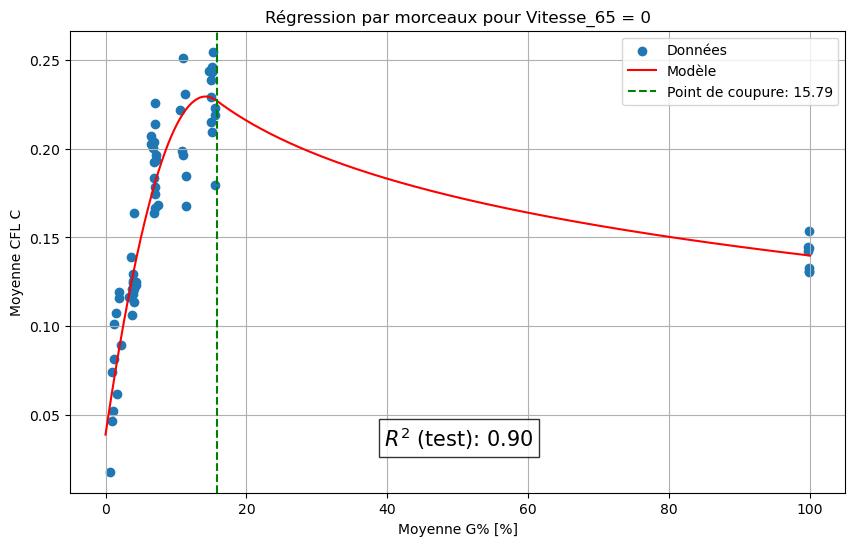

In [29]:
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1_2, b1_2, c1_2, a2_2, b2_2 = params
    glissement = x_k
    return (a1_2 + b1_2 * glissement + c1_2 * (glissement**2)) - (a2_2 + b2_2 * np.log(glissement))

# Fonction pour la contrainte de l'intercept positif
def positive_intercept_constraint(params):
    a1_2, b1_2, c1_2, a2_2, b2_2 = params
    return a1_2

# Fonction pour la contrainte de la dérivée négative
def negative_derivative_constraint(params):
    a1_2, b1_2, c1_2, a2_2, b2_2 = params
    return -b2_2

# Fonction pour la contrainte de différentiabilité
def differentiable_function_constraint(params, x_k):
    a1_2, b1_2, c1_2, a2_2, b2_2 = params
    glissement = x_k
    return (b1_2 + 2 * c1_2 * glissement) - (b2_2 / glissement)

# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1_2, b1_2, c1_2, a2_2, b2_2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1_2 + b1_2 * X['Moyenne G% [%]'] + c1_2 * (X['Moyenne G% [%]']**2),
                      a2_2 + b2_2 * np.log(X['Moyenne G% [%]']))
    x = np.linspace(0, x_k, 1000)
    f = lambda x: a1_2 + b1_2 * x + c1_2 * x**2
    y_reg = f(x)
    
    g_max_real = X['Moyenne G% [%]'].iloc[np.argmax(y)]
    g_max_pred = x[np.argmax(y_reg)]
    max_abscissa_diff = abs(g_max_real - g_max_pred)
    reg = 0 * np.sum(abs(params[3:])) + 0.003 * a1_2
    return mean_squared_error(y, y_pred) + 0 * max_abscissa_diff + reg

data = ncb2
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)
a = X['Moyenne G% [%]'].apply(descritisation_ncb)
X["g2"] = X['Moyenne G% [%]']**2
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=a, random_state=123)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k_2 = None

x_values = np.linspace(12, 18, 20)  # Contraindre x_k entre 11 et 12
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [0.05, 0.1, -0.001, 0.01, 0.01]
    constraints = [
        {'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)},
        {'type': 'ineq', 'fun': positive_intercept_constraint},
        {'type': 'ineq', 'fun': negative_derivative_constraint},
        {'type': 'eq', 'fun': differentiable_function_constraint, 'args': (x_k,)}
    ]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)
    if solution.success:
        a1_2, b1_2, c1_2, a2_2, b2_2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1_2 + b1_2 * X_train['Moyenne G% [%]'] + c1_2 * (X_train['Moyenne G% [%]']**2),
                                a2_2 + b2_2 * np.log(X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k_2 = x_k

# Affichage des résultats
a1_2, b1_2, c1_2, a2_2, b2_2 = best_params
print(f"Meilleur point de coupure: {best_x_k_2}")
print(f"Paramètres: a1={a1_2}, b1={b1_2}, c1={c1_2}, a2={a2_2}, b2={b2_2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k_2
y_pred_test = np.where(mask_test,
                       a1_2 + b1_2 * X_test['Moyenne G% [%]'] + c1_2 * (X_test['Moyenne G% [%]']**2),
                       a2_2 + b2_2 * np.log(X_test['Moyenne G% [%]']))
r2_test_2 = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test_2}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k_2,
                     a1_2 + b1_2 * x + c1_2 * (x**2),
                     a2_2 + b2_2 * np.log(x))

# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k_2, color='green', linestyle='--', label=f'Point de coupure: {best_x_k_2:.2f}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = 0')
plt.annotate(f'$R^2$ (test): {r2_test_2:.2f}', xy=(0.405, 0.1), xycoords='axes fraction', 
             fontsize=15, bbox=dict(facecolor='white', alpha=0.8))
plt.legend()
plt.grid()
plt.show()


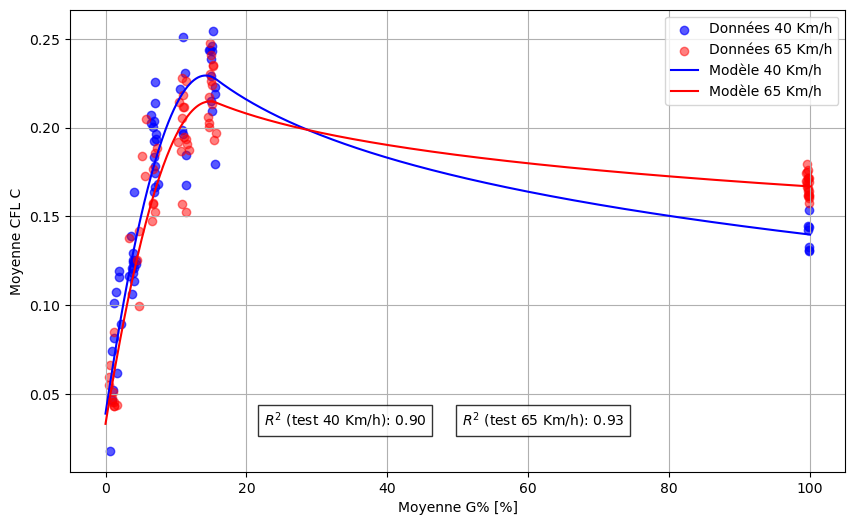

In [30]:
x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v2 = np.where(x <= best_x_k_2,
                     a1_2 + b1_2 * x + c1_2 * (x**2),
                     a2_2 + b2_2 * np.log(x))
y_pred_v1 = np.where(x <= best_x_k,
                     a1 + b1 * x + c1 * (x**2),
                     a2 + b2 * np.log(x))
# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(ncb2['Moyenne G% [%]'], ncb2['Moyenne CFL C'], label='Données 40 Km/h', alpha = 0.65, color = "b")
plt.scatter(ncb['Moyenne G% [%]'], ncb['Moyenne CFL C'], label='Données 65 Km/h', color = "red" ,alpha = 0.5)

plt.plot(x, y_pred_v2, color='b', label='Modèle 40 Km/h')
plt.plot(x, y_pred_v1, color='r', label='Modèle 65 Km/h')



plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
#plt.title(f'Régression par morceaux pour Vitesse_65 = 1')
plt.annotate(f'$R^2$ (test 65 Km/h): {r2_test:.2f}', xy=(0.505, 0.1), xycoords='axes fraction', 
             fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
plt.annotate(f'$R^2$ (test 40 Km/h): {r2_test_2:.2f}', xy=(0.250, 0.1), xycoords='axes fraction', 
             fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
plt.legend()
plt.grid()
plt.show()


In [31]:
max(y_pred_v2)- max(y_pred_v1)


0.014606138940761293

## NC.C.


In [32]:
def descritisation_ncc(x):
    if x<2:
        return "2"
    if x<4:
        return "4"
    if x<6:
        return "6"
    elif x< 8:
        return "8"
    elif x< 11:
        return "11"
    elif x< 14:
        return "14"
    elif x< 16:
        return "16"
    else:
        return "more"


Meilleur point de coupure: 13.0
Paramètres: a1=0.051245467008241584, b1=0.03435668022613107, c1=-0.0015607670831270285, a2=0.3076137185890924, b2=-0.0019087468284965956, c2=-0.02865594421061068
R² train: 0.8293307410984984
R² test: 0.7733311193297365


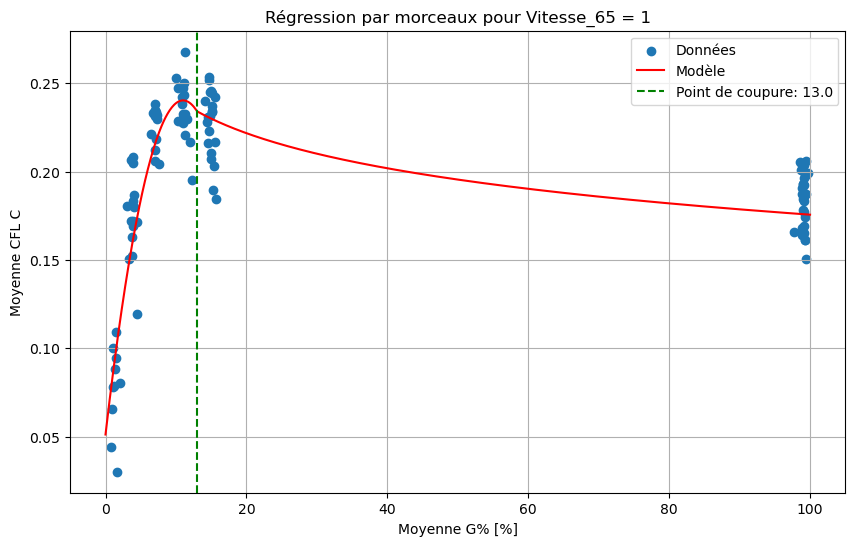

CPU times: total: 1.91 s
Wall time: 1.91 s


In [33]:
%%time
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2, c2 = params
    glissement = x_k
    return (a1 +b1 * glissement + c1 * (glissement**2) ) - (a2  + c2 * np.log(glissement))


# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1,  a2, b2, c2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 *(X['Moyenne G% [%]']**2) ,
                      a2  + c2 * np.log(X['Moyenne G% [%]']))
    x = np.linspace(0, x_k, 1000)
    f = lambda x: a1 + b1 * x + c1 * x**2
    y_reg = f(x)
    
    g_max_real = X['Moyenne G% [%]'].iloc[np.argmax(y)]
    g_max_pred = x[np.argmax(y_reg)]
    max_abscissa_diff = abs(g_max_real  - g_max_pred)**2
    reg = 0.0003 * np.sum(abs(params[3:])) 
    
    return mean_squared_error(y, y_pred) + 0.004*max_abscissa_diff+reg


data = ncc
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)

a = X['Moyenne G% [%]'].apply(descritisation_ncc)
# X["g3"] = X['Moyenne G% [%]']**3
# X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]']**2
# X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  stratify = a , random_state=30)
# 30 75 5
# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(11,13, 10)  # Contraindre x_k entre 15 et 20
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [0.5, 0.1, -0.001, 0.4, -0.001, 0.01]
    constraints = [{'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)}]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)    
    if solution.success:
        a1, b1, c1 , a2, b2, c2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 *(X_train['Moyenne G% [%]']**2) ,
                                  a2 +  + c2 * np.log( X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k


# Affichage des résultats
a1, b1, c1, a2, b2, c2= best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}, c2={c2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                                a1 + b1 * X_test['Moyenne G% [%]'] + c1 *(X_test['Moyenne G% [%]']**2) ,
                                  a2  + c2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                    a1 +b1* x + c1 * (x**2) ,
                    a2  +c2 * np.log(x))
    
# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = {1}')
plt.legend()
plt.grid()
plt.show()

Meilleur point de coupure: 11.105263157894736
Paramètres: a1=0.03508575425469049, b1=0.03899523192012726, c1=-0.0018510181313859083, a2=0.296451962102173, b2=-0.023508231820731366
R² train: 0.818
R² test: 0.829


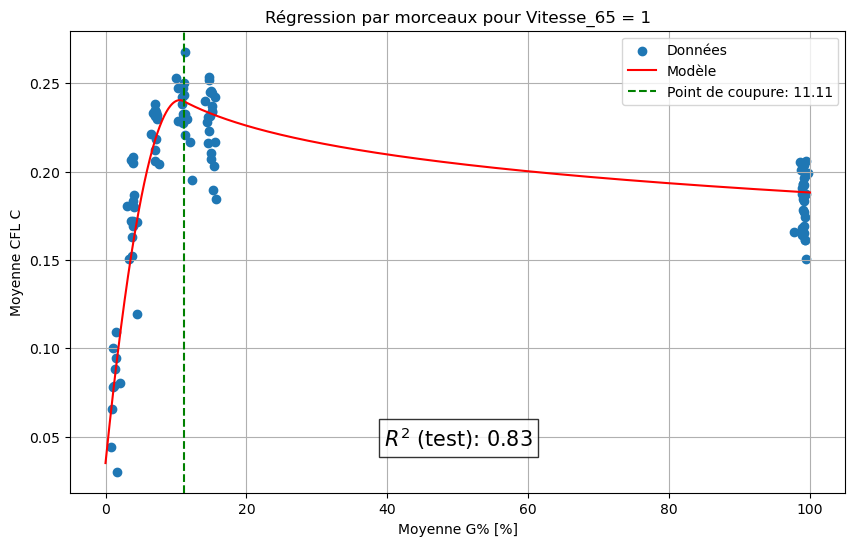

In [34]:
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2 = params
    glissement = x_k
    return (a1 + b1 * glissement + c1 * (glissement**2)) - (a2 + b2 * np.log(glissement))

# Fonction pour la contrainte de l'intercept positif
def positive_intercept_constraint(params):
    a1, b1, c1, a2, b2 = params
    return a1

# Fonction pour la contrainte de la dérivée négative
def negative_derivative_constraint(params):
    a1, b1, c1, a2, b2 = params
    return -b2

# Fonction pour la contrainte de différentiabilité
def differentiable_function_constraint(params, x_k):
    a1, b1, c1, a2, b2 = params
    glissement = x_k
    return (b1 + 2 * c1 * glissement) - (b2 / glissement)

# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1, a2, b2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 * (X['Moyenne G% [%]']**2),
                      a2 + b2 * np.log(X['Moyenne G% [%]']))
    x = np.linspace(0, x_k, 1000)
    f = lambda x: a1 + b1 * x + c1 * x**2
    y_reg = f(x)
    
    g_max_real = X['Moyenne G% [%]'].iloc[np.argmax(y)]
    g_max_pred = x[np.argmax(y_reg)]
    max_abscissa_diff = abs(g_max_real - g_max_pred)
    reg = 0.0003 * np.sum(abs(params[3:])) +0.0025*a1
    return mean_squared_error(y, y_pred) + 0.0005 * max_abscissa_diff + reg

# Données
data = ncc
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)
a = X['Moyenne G% [%]'].apply(descritisation_ncc)
X["g2"] = X['Moyenne G% [%]']**2
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=a, random_state=53)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(11, 13, 20)  
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [0.01, 0.1, -0.001, 0.01, 0.01]
    constraints = [
        {'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)},
        {'type': 'ineq', 'fun': positive_intercept_constraint},
        {'type': 'ineq', 'fun': negative_derivative_constraint},
        {'type': 'eq', 'fun': differentiable_function_constraint, 'args': (x_k,)}
    ]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)
    if solution.success:
        a1, b1, c1, a2, b2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 * (X_train['Moyenne G% [%]']**2),
                                a2 + b2 * np.log(X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k

# Affichage des résultats
a1, b1, c1, a2, b2 = best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}")
print(f"R² train: {best_r2:.3f}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                       a1 + b1 * X_test['Moyenne G% [%]'] + c1 * (X_test['Moyenne G% [%]']**2),
                       a2 + b2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test :.3f}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                     a1 + b1 * x + c1 * (x**2),
                     a2 + b2 * np.log(x))

# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k:.2f}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = 1')
plt.annotate(f'$R^2$ (test): {r2_test:.2f}', xy=(0.405, 0.1), xycoords='axes fraction', 
             fontsize=15, bbox=dict(facecolor='white', alpha=0.8))
plt.legend()
plt.grid()
plt.show()


In [35]:
a1_2=0.03508575425469049
b1_2=0.03899523192012726
c1_2=-0.0018510181313859083
a2_2=0.296451962102173
b2_2=-0.023508231820731366

##### 40Km/h

Meilleur point de coupure: 11.142857142857142
Paramètres: a1=0.009407072473976034, b1=0.049920995722763914, c1=-0.0024420654994262046, a2=0.3833976185523055, b2=-0.05016712923258592
R² train: 0.7820158179506669
R² test: 0.9040544342286695


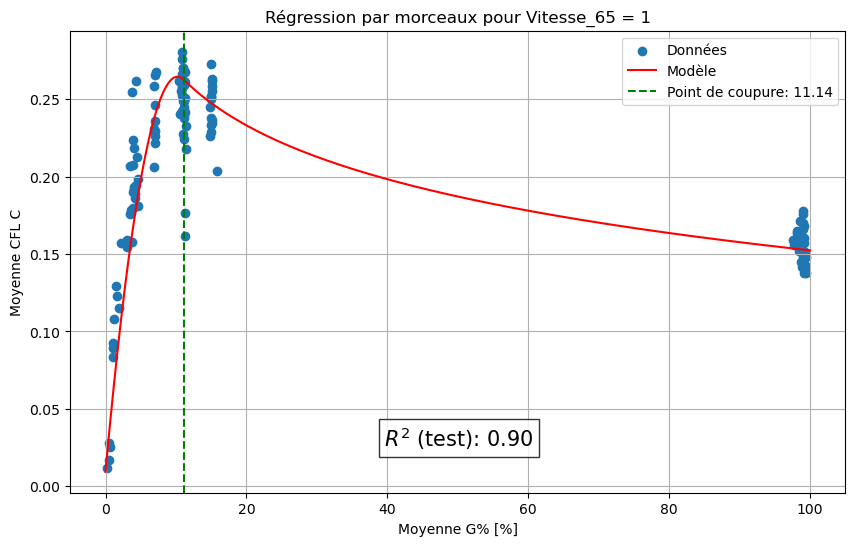

In [36]:


# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1_2, b1_2, c1_2, a2_2, b2_2 = params
    glissement = x_k
    return (a1_2 + b1_2 * glissement + c1_2 * (glissement**2)) - (a2_2 + b2_2 * np.log(glissement))

# Fonction pour la contrainte de l'intercept positif
def positive_intercept_constraint(params):
    a1_2, b1_2, c1_2, a2_2, b2_2 = params
    return a1_2

# Fonction pour la contrainte de la dérivée négative
def negative_derivative_constraint(params):
    a1_2, b1_2, c1_2, a2_2, b2_2 = params
    return -b2_2

# Fonction pour la contrainte de différentiabilité
def differentiable_function_constraint(params, x_k):
    a1_2, b1_2, c1_2, a2_2, b2_2 = params
    glissement = x_k
    return (b1_2 + 2 * c1_2 * glissement) - (b2_2 / glissement)

# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1_2, b1_2, c1_2, a2_2, b2_2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1_2 + b1_2 * X['Moyenne G% [%]'] + c1_2 * (X['Moyenne G% [%]']**2),
                      a2_2 + b2_2 * np.log(X['Moyenne G% [%]']))
    x = np.linspace(0, x_k, 1000)
    f = lambda x: a1_2 + b1_2 * x + c1_2 * x**2
    y_reg = f(x)
    
    g_max_real = X['Moyenne G% [%]'].iloc[np.argmax(y)]
    g_max_pred = x[np.argmax(y_reg)]
    max_abscissa_diff = abs(g_max_real - g_max_pred)
    reg = 0 * np.sum(abs(params[3:])) + 0.008 * a1_2
    return mean_squared_error(y, y_pred) + 0.001 * max_abscissa_diff + reg

# Données
data = ncc2
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)
a = X['Moyenne G% [%]'].apply(descritisation_ncc)
X["g2"] = X['Moyenne G% [%]']**2
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=a, random_state=31)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k_2 = None

x_values = np.linspace(11, 13, 15)  # Contraindre x_k entre 11 et 12
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [0.05, 0.1, -0.001, 0.01, 0.01]
    constraints = [
        {'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)},
        {'type': 'ineq', 'fun': positive_intercept_constraint},
        {'type': 'ineq', 'fun': negative_derivative_constraint},
        {'type': 'eq', 'fun': differentiable_function_constraint, 'args': (x_k,)}
    ]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)
    if solution.success:
        a1_2, b1_2, c1_2, a2_2, b2_2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1_2 + b1_2 * X_train['Moyenne G% [%]'] + c1_2 * (X_train['Moyenne G% [%]']**2),
                                a2_2 + b2_2 * np.log(X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k_2 = x_k

# Affichage des résultats
a1_2, b1_2, c1_2, a2_2, b2_2 = best_params
print(f"Meilleur point de coupure: {best_x_k_2}")
print(f"Paramètres: a1={a1_2}, b1={b1_2}, c1={c1_2}, a2={a2_2}, b2={b2_2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k_2
y_pred_test = np.where(mask_test,
                       a1_2 + b1_2 * X_test['Moyenne G% [%]'] + c1_2 * (X_test['Moyenne G% [%]']**2),
                       a2_2 + b2_2 * np.log(X_test['Moyenne G% [%]']))
r2_test_2 = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test_2}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k_2,
                     a1_2 + b1_2 * x + c1_2 * (x**2),
                     a2_2 + b2_2 * np.log(x))

# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k_2, color='green', linestyle='--', label=f'Point de coupure: {best_x_k_2:.2f}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = 1')
plt.annotate(f'$R^2$ (test): {r2_test_2:.2f}', xy=(0.405, 0.1), xycoords='axes fraction', 
             fontsize=15, bbox=dict(facecolor='white', alpha=0.8))
plt.legend()
plt.grid()
plt.show()


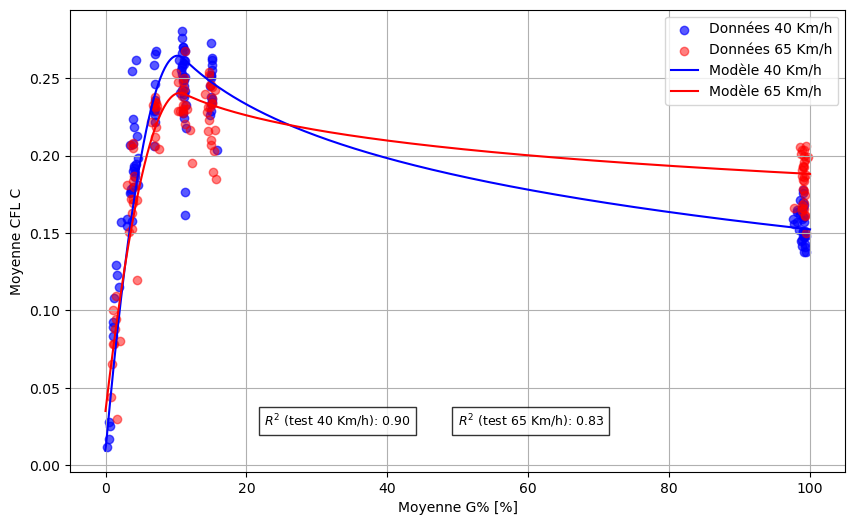

In [37]:
x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v2 = np.where(x <= best_x_k_2,
                     a1_2 + b1_2 * x + c1_2 * (x**2),
                     a2_2 + b2_2 * np.log(x))
y_pred_v1 = np.where(x <= best_x_k,
                     a1 + b1 * x + c1 * (x**2),
                     a2 + b2 * np.log(x))
# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(ncc2['Moyenne G% [%]'], ncc2['Moyenne CFL C'], label='Données 40 Km/h', alpha = 0.65, color = "b")
plt.scatter(ncc['Moyenne G% [%]'], ncc['Moyenne CFL C'], label='Données 65 Km/h', color = "red" ,alpha = 0.5)

plt.plot(x, y_pred_v2, color='b', label='Modèle 40 Km/h', alpha = 1)
plt.plot(x, y_pred_v1, color='r', label='Modèle 65 Km/h')



plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
#plt.title(f'Régression par morceaux pour Vitesse_65 = 1')
plt.annotate(f'$R^2$ (test 65 Km/h): {r2_test:.2f}', xy=(0.500, 0.1), xycoords='axes fraction', 
             fontsize=9, bbox=dict(facecolor='white', alpha=0.8))
plt.annotate(f'$R^2$ (test 40 Km/h): {r2_test_2:.2f}', xy=(0.250, 0.1), xycoords='axes fraction', 
             fontsize=9, bbox=dict(facecolor='white', alpha=0.8))
plt.legend()
plt.grid()
plt.show()


In [38]:
max(y_pred_v2)- max(y_pred_v1)


0.02406749223578336

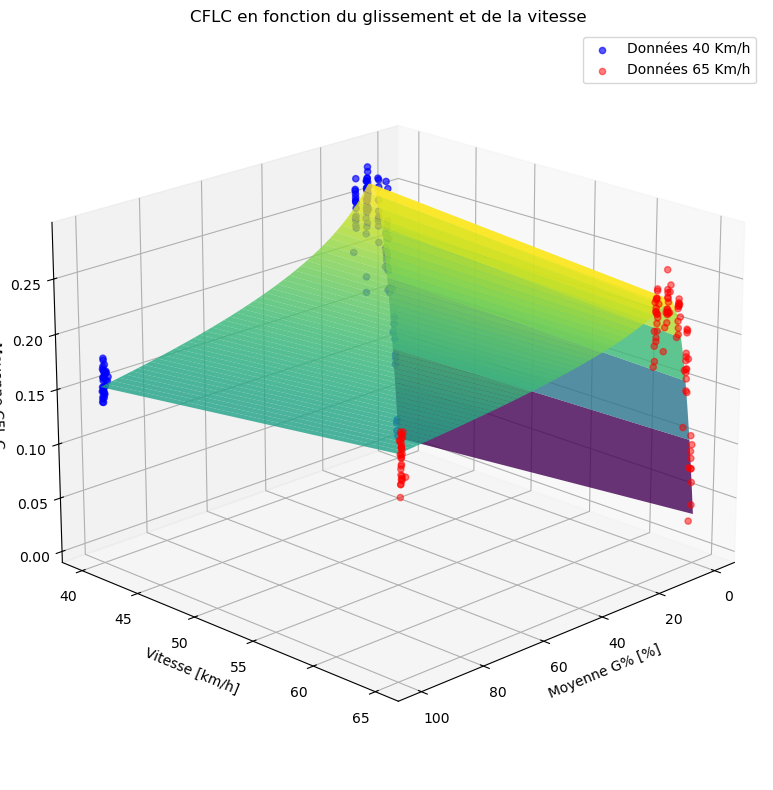

In [39]:
from mpl_toolkits.mplot3d import Axes3D

# Create data points for the x-axis (Moyenne G%)
x = np.linspace(0, 100, 1000)

# Create meshgrid for 3D surface
x_mesh, y_mesh = np.meshgrid(x, [40, 65])

# Calculate predictions for both speeds
z_pred = np.zeros_like(x_mesh)

# 40 km/h predictions
z_pred[0] = np.where(x <= best_x_k_2,
                     a1_2 + b1_2 * x + c1_2 * (x**2),
                     a2_2 + b2_2 * np.log(x))

# 65 km/h predictions
z_pred[1] = np.where(x <= best_x_k,
                     a1 + b1 * x + c1 * (x**2),
                     a2 + b2 * np.log(x))

# Create the 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
surf = ax.plot_surface(x_mesh, y_mesh, z_pred, cmap='viridis', alpha=0.8)

# Plot scatter points for actual data
ax.scatter(ncc2['Moyenne G% [%]'], 
           np.full(len(ncc2), 40), 
           ncc2['Moyenne CFL C'],
           color='blue', alpha=0.65, label='Données 40 Km/h')

ax.scatter(ncc['Moyenne G% [%]'], 
           np.full(len(ncc), 65), 
           ncc['Moyenne CFL C'],
           color='red', alpha=0.5, label='Données 65 Km/h')

# Set labels and title
ax.set_xlabel('Moyenne G% [%]')
ax.set_ylabel('Vitesse [km/h]')
ax.set_zlabel('Moyenne CFL C')
ax.set_title('CFLC en fonction du glissement et de la vitesse')

# Add legend
ax.legend()

# Adjust the viewing angle
ax.view_init(elev=20, azim=45)

plt.tight_layout()
plt.show()

In [40]:
import plotly.graph_objects as go

# Create data points for the x-axis (Moyenne G%) and y-axis (vitesse)
x = np.linspace(0, 100, 1000)
y = np.array([40, 65])

# Create a meshgrid for the 3D surface
x_mesh, y_mesh = np.meshgrid(x, y)

# Calculate predictions for the surface
z_pred = np.zeros_like(x_mesh)

# For 40 km/h predictions
z_pred[0, :] = np.where(x <= best_x_k_2,
                        a1_2 + b1_2 * x + c1_2 * (x**2),
                        a2_2 + b2_2 * np.log(x))

# For 65 km/h predictions
z_pred[1, :] = np.where(x <= best_x_k,
                        a1 + b1 * x + c1 * (x**2),
                        a2 + b2 * np.log(x))

# Create the figure
fig = go.Figure()

# Add the surface for the predictions
fig.add_trace(go.Surface(z=z_pred, x=x_mesh, y=y_mesh, colorscale='Viridis', opacity=0.75, showscale=False))

# Add scatter plot for 40 km/h data
fig.add_trace(go.Scatter3d(x=ncc2['Moyenne G% [%]'], y=np.full(len(ncc2), 40), z=ncc2['Moyenne CFL C'],
                           mode='markers', marker=dict(size=4, color='blue', opacity=0.7),
                           showlegend=False))

# Add scatter plot for 65 km/h data
fig.add_trace(go.Scatter3d(x=ncc['Moyenne G% [%]'], y=np.full(len(ncc), 65), z=ncc['Moyenne CFL C'],
                           mode='markers', marker=dict(size=4, color='red', opacity=0.7),
                           showlegend=False))

# Update layout
fig.update_layout(
    title='CFLC en fonction du glissement et de la vitesse',
    scene=dict(
        xaxis_title='Moyenne G% [%]',
        yaxis_title='Vitesse [km/h]',
        zaxis_title='Moyenne CFL C',
        camera=dict(eye=dict(x=1.6, y=-1.6, z=0.8))
    ),
    width=1200,
    height=800,
    autosize=False
)

# Show the plot
fig.show()


## Verglas

In [41]:
def descritisation_verglas(x):
    if x< 6:
        return "8"
    elif x< 11:
        return "11"
    elif x< 14:
        return "14"
    elif x< 16:
        return "16"
    else:
        return "more"

Meilleur point de coupure: 14.052631578947368
Paramètres: a1=0.06773914842864878, b1=0.011674721975474358, c1=-0.00044008605785673125, a2=0.17066761575067865, b2=-0.009752701871229563
R² train: 0.633
R² test: 0.807


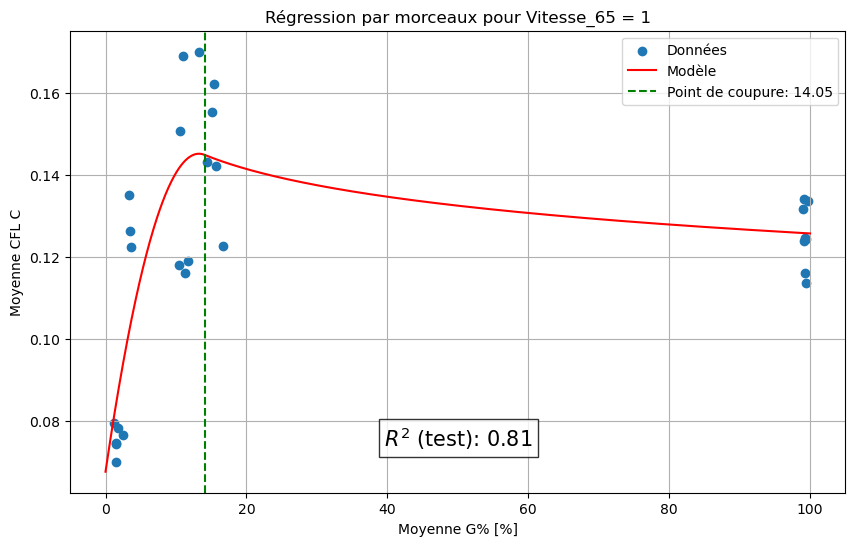

In [42]:
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2 = params
    glissement = x_k
    return (a1 + b1 * glissement + c1 * (glissement**2)) - (a2 + b2 * np.log(glissement))

# Fonction pour la contrainte de l'intercept positif
def positive_intercept_constraint(params):
    a1, b1, c1, a2, b2 = params
    return a1

# Fonction pour la contrainte de la dérivée négative
def negative_derivative_constraint(params):
    a1, b1, c1, a2, b2 = params
    return -b2

# Fonction pour la contrainte de différentiabilité
def differentiable_function_constraint(params, x_k):
    a1, b1, c1, a2, b2 = params
    glissement = x_k
    return (b1 + 2 * c1 * glissement) - (b2 / glissement)

# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1, a2, b2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 * (X['Moyenne G% [%]']**2),
                      a2 + b2 * np.log(X['Moyenne G% [%]']))
    x = np.linspace(0, x_k, 1000)
    f = lambda x: a1 + b1 * x + c1 * x**2
    y_reg = f(x)
    
    g_max_real = X['Moyenne G% [%]'].iloc[np.argmax(y)]
    g_max_pred = x[np.argmax(y_reg)]
    max_abscissa_diff = abs(g_max_real - g_max_pred)
    reg = 0.01 * np.sum(abs(params[1:3]))+0.0005 * np.sum(abs(params[3:])) +0.002*a1
    return mean_squared_error(y, y_pred) + 0.005 * max_abscissa_diff +reg

# Données
data = ver
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)
a = X['Moyenne G% [%]'].apply(descritisation_verglas)
X["g2"] = X['Moyenne G% [%]']**2
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=a, random_state=17)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(13, 18, 20)  
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [0.01, 0.1, -0.001, 0.01, 0.01]
    constraints = [
        {'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)},
        {'type': 'ineq', 'fun': positive_intercept_constraint},
        {'type': 'ineq', 'fun': negative_derivative_constraint},
        {'type': 'eq', 'fun': differentiable_function_constraint, 'args': (x_k,)}
    ]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)
    if solution.success:
        a1, b1, c1, a2, b2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 * (X_train['Moyenne G% [%]']**2),
                                a2 + b2 * np.log(X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k

# Affichage des résultats
a1, b1, c1, a2, b2 = best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}")
print(f"R² train: {best_r2:.3f}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                       a1 + b1 * X_test['Moyenne G% [%]'] + c1 * (X_test['Moyenne G% [%]']**2),
                       a2 + b2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test :.3f}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                     a1 + b1 * x + c1 * (x**2),
                     a2 + b2 * np.log(x))

# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k:.2f}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = 1')
plt.annotate(f'$R^2$ (test): {r2_test:.2f}', xy=(0.405, 0.1), xycoords='axes fraction', 
             fontsize=15, bbox=dict(facecolor='white', alpha=0.8))
plt.legend()
plt.grid()
plt.show()


##### Vitesse 40Km/h

Meilleur point de coupure: 13.0
Paramètres: a1=0.028374388502803622, b1=0.018845861793580988, c1=-0.0007484496628243564, a2=0.16735033735777116, b2=-0.007979782718089457
R² train: 0.6137637948050838
R² test: 0.7498604906175215


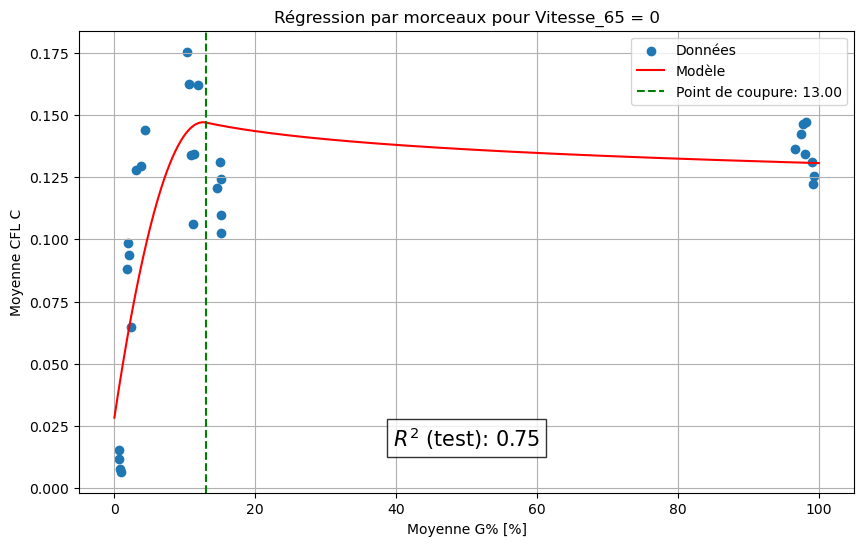

In [43]:
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1_2, b1_2, c1_2, a2_2, b2_2 = params
    glissement = x_k
    return (a1_2 + b1_2 * glissement + c1_2 * (glissement**2)) - (a2_2 + b2_2 * np.log(glissement))

# Fonction pour la contrainte de l'intercept positif
def positive_intercept_constraint(params):
    a1_2, b1_2, c1_2, a2_2, b2_2 = params
    return a1_2

# Fonction pour la contrainte de la dérivée négative
def negative_derivative_constraint(params):
    a1_2, b1_2, c1_2, a2_2, b2_2 = params
    return -b2_2

# Fonction pour la contrainte de différentiabilité
def differentiable_function_constraint(params, x_k):
    a1_2, b1_2, c1_2, a2_2, b2_2 = params
    glissement = x_k
    return (b1_2 + 2 * c1_2 * glissement) - (b2_2 / glissement)

# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1_2, b1_2, c1_2, a2_2, b2_2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1_2 + b1_2 * X['Moyenne G% [%]'] + c1_2 * (X['Moyenne G% [%]']**2),
                      a2_2 + b2_2 * np.log(X['Moyenne G% [%]']))
    x = np.linspace(0, x_k, 1000)
    f = lambda x: a1_2 + b1_2 * x + c1_2 * x**2
    y_reg = f(x)
    
    g_max_real = X['Moyenne G% [%]'].iloc[np.argmax(y)]
    g_max_pred = x[np.argmax(y_reg)]
    max_abscissa_diff = abs(g_max_real - g_max_pred)
    reg = 0 * np.sum(abs(params[3:])) + 0.003 * a1_2
    return mean_squared_error(y, y_pred) + 0 * max_abscissa_diff + reg

data = ver2
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)
a = X['Moyenne G% [%]'].apply(descritisation_verglas)
X["g2"] = X['Moyenne G% [%]']**2
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=a, random_state=17)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k_2 = None

x_values = np.linspace(13, 18, 20)  # Contraindre x_k entre 11 et 12
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [0.05, 0.1, -0.001, 0.01, 0.01]
    constraints = [
        {'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)},
        {'type': 'ineq', 'fun': positive_intercept_constraint},
        {'type': 'ineq', 'fun': negative_derivative_constraint},
        {'type': 'eq', 'fun': differentiable_function_constraint, 'args': (x_k,)}
    ]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)
    if solution.success:
        a1_2, b1_2, c1_2, a2_2, b2_2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1_2 + b1_2 * X_train['Moyenne G% [%]'] + c1_2 * (X_train['Moyenne G% [%]']**2),
                                a2_2 + b2_2 * np.log(X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k_2 = x_k

# Affichage des résultats
a1_2, b1_2, c1_2, a2_2, b2_2 = best_params
print(f"Meilleur point de coupure: {best_x_k_2}")
print(f"Paramètres: a1={a1_2}, b1={b1_2}, c1={c1_2}, a2={a2_2}, b2={b2_2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k_2
y_pred_test = np.where(mask_test,
                       a1_2 + b1_2 * X_test['Moyenne G% [%]'] + c1_2 * (X_test['Moyenne G% [%]']**2),
                       a2_2 + b2_2 * np.log(X_test['Moyenne G% [%]']))
r2_test_2 = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test_2}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k_2,
                     a1_2 + b1_2 * x + c1_2 * (x**2),
                     a2_2 + b2_2 * np.log(x))

# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k_2, color='green', linestyle='--', label=f'Point de coupure: {best_x_k_2:.2f}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = 0')
plt.annotate(f'$R^2$ (test): {r2_test_2:.2f}', xy=(0.405, 0.1), xycoords='axes fraction', 
             fontsize=15, bbox=dict(facecolor='white', alpha=0.8))
plt.legend()
plt.grid()
plt.show()


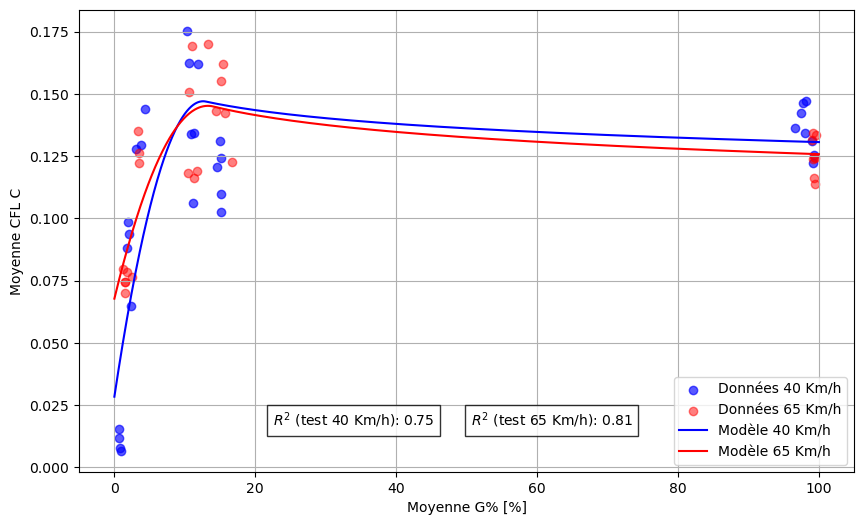

In [44]:
x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v2 = np.where(x <= best_x_k_2,
                     a1_2 + b1_2 * x + c1_2 * (x**2),
                     a2_2 + b2_2 * np.log(x))
y_pred_v1 = np.where(x <= best_x_k,
                     a1 + b1 * x + c1 * (x**2),
                     a2 + b2 * np.log(x))
# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(ver2['Moyenne G% [%]'], ver2['Moyenne CFL C'], label='Données 40 Km/h', alpha = 0.65, color = "b")
plt.scatter(ver['Moyenne G% [%]'], ver['Moyenne CFL C'], label='Données 65 Km/h', color = "red" ,alpha = 0.5)

plt.plot(x, y_pred_v2, color='b', label='Modèle 40 Km/h')
plt.plot(x, y_pred_v1, color='r', label='Modèle 65 Km/h')



plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
#plt.title(f'Régression par morceaux pour Vitesse_65 = 1')
plt.annotate(f'$R^2$ (test 65 Km/h): {r2_test:.2f}', xy=(0.505, 0.1), xycoords='axes fraction', 
             fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
plt.annotate(f'$R^2$ (test 40 Km/h): {r2_test_2:.2f}', xy=(0.250, 0.1), xycoords='axes fraction', 
             fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
plt.legend()
plt.grid()
plt.show()


In [45]:
max(y_pred_v2)- max(y_pred_v1)


0.0018424398397548225

## Glace

In [46]:
def descritisation_glace(x):
    if x< 6:
        return "8"
    elif x< 11:
        return "11"
    elif x< 14:
        return "14"
    elif x< 16:
        return "16"
    else:
        return "more"

Meilleur point de coupure: 17.0
Paramètres: a1=4.959170474879524e-14, b1=0.012411250316351433, c1=-0.00039814354367962655, a2=0.1501433283066601, b2=-0.01913571286949212
R² train: 0.734
R² test: 0.865


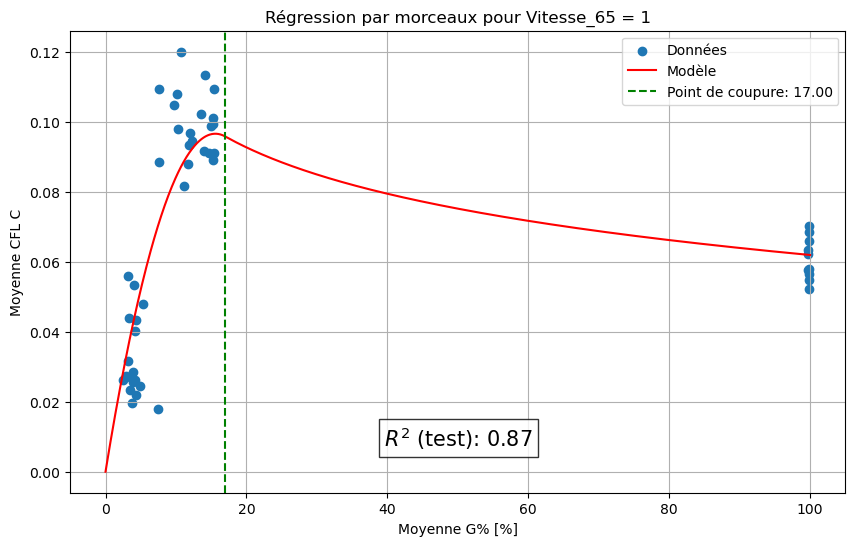

In [47]:
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2 = params
    glissement = x_k
    return (a1 + b1 * glissement + c1 * (glissement**2)) - (a2 + b2 * np.log(glissement))

# Fonction pour la contrainte de l'intercept positif
def positive_intercept_constraint(params):
    a1, b1, c1, a2, b2 = params
    return a1

# Fonction pour la contrainte de la dérivée négative
def negative_derivative_constraint(params):
    a1, b1, c1, a2, b2 = params
    return -b2

# Fonction pour la contrainte de différentiabilité
def differentiable_function_constraint(params, x_k):
    a1, b1, c1, a2, b2 = params
    glissement = x_k
    return (b1 + 2 * c1 * glissement) - (b2 / glissement)

# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1, a2, b2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 * (X['Moyenne G% [%]']**2),
                      a2 + b2 * np.log(X['Moyenne G% [%]']))
    x = np.linspace(0, x_k, 1000)
    f = lambda x: a1 + b1 * x + c1 * x**2
    y_reg = f(x)
    
    g_max_real = X['Moyenne G% [%]'].iloc[np.argmax(y)]
    g_max_pred = x[np.argmax(y_reg)]
    max_abscissa_diff = abs(g_max_real - g_max_pred)
    reg = 0.0055 * np.sum(abs(params[1:3]))+0.0001 * np.sum(abs(params[3:])) + 10*a1
    return mean_squared_error(y, y_pred) + 0.001 * max_abscissa_diff +reg

# Données
data = gla
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)
a = X['Moyenne G% [%]'].apply(descritisation_glace)
X["g2"] = X['Moyenne G% [%]']**2
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=a, random_state=123)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(11, 17, 20)  
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [0.01, 0.1, -0.001, 0.01, 0.01]
    constraints = [
        {'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)},
        {'type': 'ineq', 'fun': positive_intercept_constraint},
        {'type': 'ineq', 'fun': negative_derivative_constraint},
        {'type': 'eq', 'fun': differentiable_function_constraint, 'args': (x_k,)}
    ]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)
    if solution.success:
        a1, b1, c1, a2, b2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 * (X_train['Moyenne G% [%]']**2),
                                a2 + b2 * np.log(X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k

# Affichage des résultats
a1, b1, c1, a2, b2 = best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}")
print(f"R² train: {best_r2:.3f}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                       a1 + b1 * X_test['Moyenne G% [%]'] + c1 * (X_test['Moyenne G% [%]']**2),
                       a2 + b2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test :.3f}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                     a1 + b1 * x + c1 * (x**2),
                     a2 + b2 * np.log(x))

# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k:.2f}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = 1')
plt.annotate(f'$R^2$ (test): {r2_test:.2f}', xy=(0.405, 0.1), xycoords='axes fraction', 
             fontsize=15, bbox=dict(facecolor='white', alpha=0.8))
plt.legend()
plt.grid()
plt.show()


In [48]:
a1_3=4.959170474879524e-14
b1_3=0.012411250316351433
c1_3=-0.00039814354367962655
a2_3=0.1501433283066601
b2_3=-0.01913571286949212

##### Vitesse 40Km/h

Meilleur point de coupure: 15.0
Paramètres: a1=6.023086243442598e-18, b1=0.010060577136089002, c1=-0.0003435023645835381, a2=0.0835521473305614, b2=-0.0036674070212592714
R² train: 0.6868148116585173
R² test: 0.6614556726084451


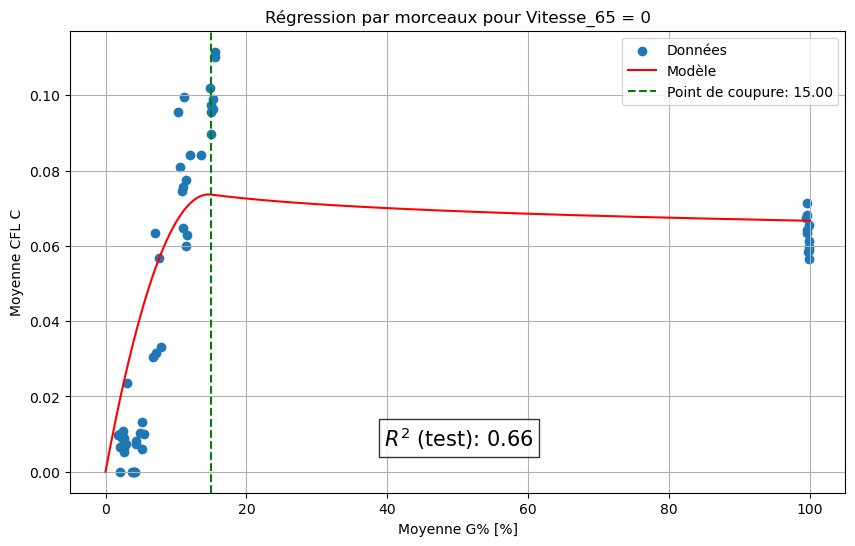

In [49]:
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1_2, b1_2, c1_2, a2_2, b2_2 = params
    glissement = x_k
    return (a1_2 + b1_2 * glissement + c1_2 * (glissement**2)) - (a2_2 + b2_2 * np.log(glissement))

# Fonction pour la contrainte de l'intercept positif
def positive_intercept_constraint(params):
    a1_2, b1_2, c1_2, a2_2, b2_2 = params
    return a1_2

# Fonction pour la contrainte de la dérivée négative
def negative_derivative_constraint(params):
    a1_2, b1_2, c1_2, a2_2, b2_2 = params
    return -b2_2

# Fonction pour la contrainte de différentiabilité
def differentiable_function_constraint(params, x_k):
    a1_2, b1_2, c1_2, a2_2, b2_2 = params
    glissement = x_k
    return (b1_2 + 2 * c1_2 * glissement) - (b2_2 / glissement)

# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1_2, b1_2, c1_2, a2_2, b2_2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1_2 + b1_2 * X['Moyenne G% [%]'] + c1_2 * (X['Moyenne G% [%]']**2),
                      a2_2 + b2_2 * np.log(X['Moyenne G% [%]']))
    x = np.linspace(0, x_k, 1000)
    f = lambda x: a1_2 + b1_2 * x + c1_2 * x**2
    y_reg = f(x)
    
    g_max_real = X['Moyenne G% [%]'].iloc[np.argmax(y)]
    g_max_pred = x[np.argmax(y_reg)]
    max_abscissa_diff = abs(g_max_real - g_max_pred)
    reg = 0 * np.sum(abs(params[:])) + 0.003 * a1_2
    return mean_squared_error(y, y_pred) + 0 * max_abscissa_diff + reg 
data = gla2
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)
a = X['Moyenne G% [%]'].apply(descritisation_glace)
X["g2"] = X['Moyenne G% [%]']**2
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=a, random_state=123)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k_2 = None

x_values = np.linspace(11, 15, 20)  # Contraindre x_k entre 11 et 12
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [0.05, 0.1, -0.001, 0.01, 0.01]
    constraints = [
        {'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)},
        {'type': 'ineq', 'fun': positive_intercept_constraint},
        {'type': 'ineq', 'fun': negative_derivative_constraint},
        {'type': 'eq', 'fun': differentiable_function_constraint, 'args': (x_k,)}
    ]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)
    if solution.success:
        a1_2, b1_2, c1_2, a2_2, b2_2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1_2 + b1_2 * X_train['Moyenne G% [%]'] + c1_2 * (X_train['Moyenne G% [%]']**2),
                                a2_2 + b2_2 * np.log(X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k_2 = x_k

# Affichage des résultats
a1_2, b1_2, c1_2, a2_2, b2_2 = best_params
print(f"Meilleur point de coupure: {best_x_k_2}")
print(f"Paramètres: a1={a1_2}, b1={b1_2}, c1={c1_2}, a2={a2_2}, b2={b2_2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k_2
y_pred_test = np.where(mask_test,
                       a1_2 + b1_2 * X_test['Moyenne G% [%]'] + c1_2 * (X_test['Moyenne G% [%]']**2),
                       a2_2 + b2_2 * np.log(X_test['Moyenne G% [%]']))
r2_test_2 = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test_2}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k_2,
                     a1_2 + b1_2 * x + c1_2 * (x**2),
                     a2_2 + b2_2 * np.log(x))

# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k_2, color='green', linestyle='--', label=f'Point de coupure: {best_x_k_2:.2f}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = 0')
plt.annotate(f'$R^2$ (test): {r2_test_2:.2f}', xy=(0.405, 0.1), xycoords='axes fraction', 
             fontsize=15, bbox=dict(facecolor='white', alpha=0.8))
plt.legend()
plt.grid()
plt.show()


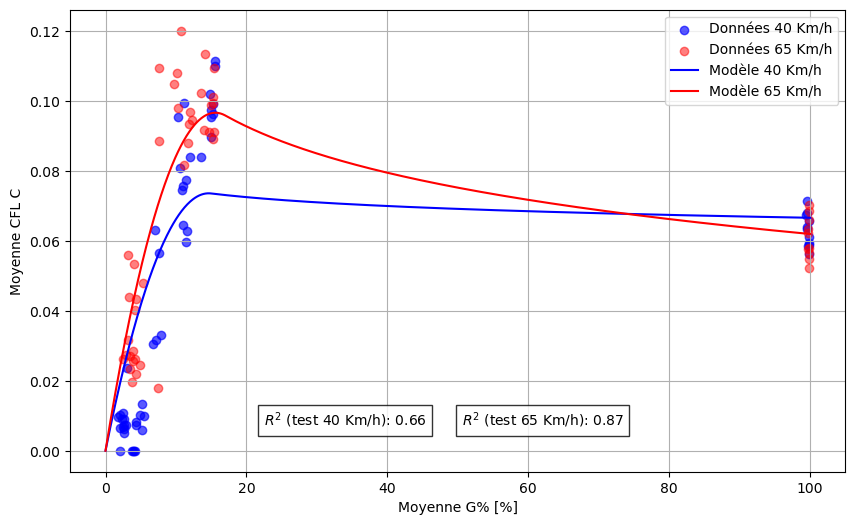

In [50]:
x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v2 = np.where(x <= best_x_k_2,
                     a1_2 + b1_2 * x + c1_2 * (x**2),
                     a2_2 + b2_2 * np.log(x))
y_pred_v1 = np.where(x <= best_x_k,
                     a1 + b1 * x + c1 * (x**2),
                     a2 + b2 * np.log(x))
# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(gla2['Moyenne G% [%]'], gla2['Moyenne CFL C'], label='Données 40 Km/h', alpha = 0.65, color = "b")
plt.scatter(gla['Moyenne G% [%]'], gla['Moyenne CFL C'], label='Données 65 Km/h', color = "red" ,alpha = 0.5)

plt.plot(x, y_pred_v2, color='b', label='Modèle 40 Km/h')
plt.plot(x, y_pred_v1, color='r', label='Modèle 65 Km/h')



plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
#plt.title(f'Régression par morceaux pour Vitesse_65 = 1')
plt.annotate(f'$R^2$ (test 65 Km/h): {r2_test:.2f}', xy=(0.505, 0.1), xycoords='axes fraction', 
             fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
plt.annotate(f'$R^2$ (test 40 Km/h): {r2_test_2:.2f}', xy=(0.250, 0.1), xycoords='axes fraction', 
             fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
plt.legend()
plt.grid()
plt.show()


In [51]:
max(y_pred_v2)- max(y_pred_v1)


-0.023059194243530118

## slush

In [52]:
def descritisation_slh(x):
    if x<0.5:
        return "0.5"
    if x<1:
        return "1"
    if x<4:
        return "4"

    elif x< 14:
        return "14"
    else:
        return "more"


Meilleur point de coupure: 12.777777777777779
Paramètres: a1=0.011007034968593165, b1=0.012213285615798595, c1=-0.000465400338150339, a2=0.05262467137019173, b2=0.014940675925267308, c2=0.015093707662323525
R² train: 0.703712528625986
R² test: 0.7028763626986025


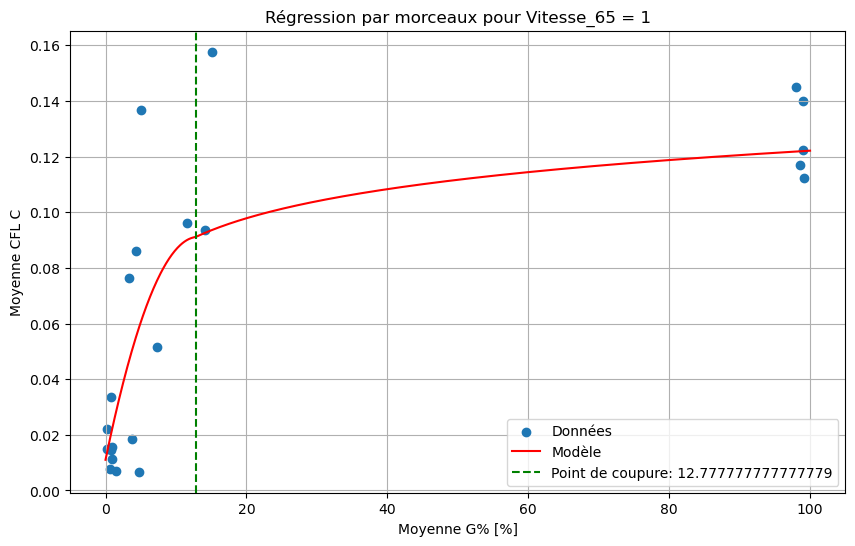

CPU times: total: 1.53 s
Wall time: 1.57 s


In [53]:
%%time
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2, c2 = params
    glissement = x_k
    return (a1 +b1 * glissement + c1 * (glissement**2) ) - (a2  + c2 * np.log(glissement))


# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1,  a2, b2, c2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 *(X['Moyenne G% [%]']**2) ,
                      a2  + c2 * np.log(X['Moyenne G% [%]']))
    x = np.linspace(0, x_k, 1000)
    f = lambda x: a1 + b1 * x + c1 * x**2
    y_reg = f(x)
    
    g_max_real = X['Moyenne G% [%]'].iloc[np.argmax(y)]
    g_max_pred = x[np.argmax(y_reg)]
    max_abscissa_diff = abs(g_max_real  - g_max_pred)**2
    reg = 0.0020 * np.sum(abs(params[3:])) 
    
    return mean_squared_error(y, y_pred) + 0.003*max_abscissa_diff + reg


data = slh
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)

a = X['Moyenne G% [%]'].apply(descritisation_slh)
# X["g3"] = X['Moyenne G% [%]']**3
# X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]']**2
# X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  stratify = a , random_state=0)# 19 20 61
# 40 0 11 26c0.002 90
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(11,13, 10)  # Contraindre x_k entre 15 et 20
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [0.5, 0.1, -0.001, 0.4, -0.001, 0.01]
    constraints = [{'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)}]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)    
    if solution.success:
        a1, b1, c1 , a2, b2, c2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 *(X_train['Moyenne G% [%]']**2) ,
                                  a2 +  + c2 * np.log( X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k


# Affichage des résultats
a1, b1, c1, a2, b2, c2= best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}, c2={c2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                                a1 + b1 * X_test['Moyenne G% [%]'] + c1 *(X_test['Moyenne G% [%]']**2) ,
                                  a2  + c2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                    a1 +b1* x + c1 * (x**2) ,
                    a2  +c2 * np.log(x))
    
# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = {1}')
plt.legend()
plt.grid()
plt.show()

Meilleur point de coupure: 15.0
Paramètres: a1=0.005491718931275806, b1=0.012319185280966882, c1=-0.0003878847645289846, a2=0.07527598002760713, b2=0.01023963517646813
R² train: 0.695
R² test: 0.759


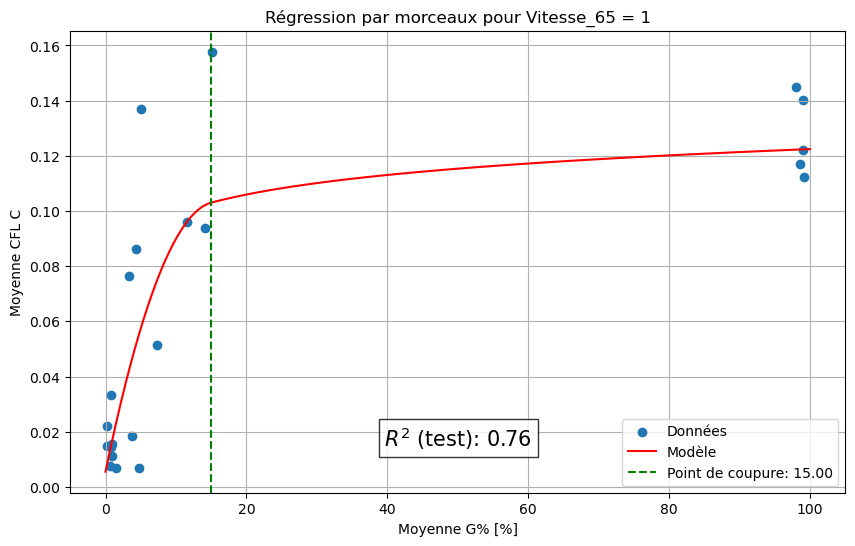

In [54]:
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1, b1, c1, a2, b2 = params
    glissement = x_k
    return (a1 + b1 * glissement + c1 * (glissement**2)) - (a2 + b2 * np.log(glissement))

# Fonction pour la contrainte de l'intercept positif
def positive_intercept_constraint(params):
    a1, b1, c1, a2, b2 = params
    return a1

# Fonction pour la contrainte de la dérivée négative
def negative_derivative_constraint(params):
    a1, b1, c1, a2, b2 = params
    return b2

# Fonction pour la contrainte de différentiabilité
def differentiable_function_constraint(params, x_k):
    a1, b1, c1, a2, b2 = params
    glissement = x_k
    return (b1 + 2 * c1 * glissement) - (b2 / glissement)

# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1, a2, b2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 * (X['Moyenne G% [%]']**2),
                      a2 + b2 * np.log(X['Moyenne G% [%]']))
    x = np.linspace(0, x_k, 1000)
    f = lambda x: a1 + b1 * x + c1 * x**2
    y_reg = f(x)
    
    g_max_real = X['Moyenne G% [%]'].iloc[np.argmax(y)]
    g_max_pred = x[np.argmax(y_reg)]
    max_abscissa_diff = abs(g_max_real - g_max_pred)
    reg = 0.000 * np.sum(abs(params[1:]))+ 0.005*a1
    return mean_squared_error(y, y_pred)  +reg

# Données
data = slh
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)
a = X['Moyenne G% [%]'].apply(descritisation_slh)
X["g2"] = X['Moyenne G% [%]']**2
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=a, random_state=0)
# 40 0 11 26c0.002 90

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k = None

x_values = np.linspace(15, 18, 20)  
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [0.01, 0.1, -0.001, 0.01, 0.01]
    constraints = [
        {'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)},
        {'type': 'ineq', 'fun': positive_intercept_constraint},
        {'type': 'ineq', 'fun': negative_derivative_constraint},
        {'type': 'eq', 'fun': differentiable_function_constraint, 'args': (x_k,)}
    ]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)
    if solution.success:
        a1, b1, c1, a2, b2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1 + b1 * X_train['Moyenne G% [%]'] + c1 * (X_train['Moyenne G% [%]']**2),
                                a2 + b2 * np.log(X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k = x_k

# Affichage des résultats
a1, b1, c1, a2, b2 = best_params
print(f"Meilleur point de coupure: {best_x_k}")
print(f"Paramètres: a1={a1}, b1={b1}, c1={c1}, a2={a2}, b2={b2}")
print(f"R² train: {best_r2:.3f}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k
y_pred_test = np.where(mask_test,
                       a1 + b1 * X_test['Moyenne G% [%]'] + c1 * (X_test['Moyenne G% [%]']**2),
                       a2 + b2 * np.log(X_test['Moyenne G% [%]']))
r2_test = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test :.3f}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k,
                     a1 + b1 * x + c1 * (x**2),
                     a2 + b2 * np.log(x))

# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k, color='green', linestyle='--', label=f'Point de coupure: {best_x_k:.2f}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = 1')
plt.annotate(f'$R^2$ (test): {r2_test:.2f}', xy=(0.405, 0.1), xycoords='axes fraction', 
             fontsize=15, bbox=dict(facecolor='white', alpha=0.8))
plt.legend()
plt.grid()
plt.show()


En definissant les contraintes, pour la troisieme et celle qui declare que le minimum apres le point de coupure doit etre au glissement consigne 100% on a fait un exeption pour le slush, c'est à dire le maximum de la courbe doit etre au glissement consigne 100% et le modele apres le point de coupure doit etre croissant.

Pour les formules des modeles precedents, pour les valeurs reelles des coeficients, ils sont de 18 chiffres apres la virgules, mais pour des raisons de clarté on n'a pris qu'une precision de 10e-5

In [55]:
##### Vitesse 40Km/h

Meilleur point de coupure: 18.0
Paramètres: a1=2.7283427390735353e-18, b1=0.01914479151214881, c1=-0.0005317997642263558, a2=0.1723031236093393, b2=3.9196750389460975e-20
R² train: 0.9520206701578279
R² test: 0.924301486458931


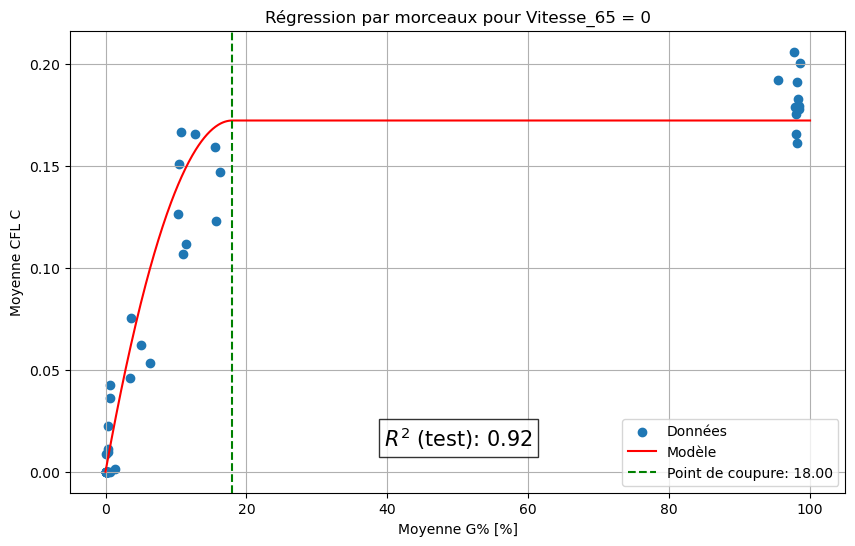

In [56]:
# Fonction pour la contrainte d'intersection
def intersection_constraint(params, x_k):
    a1_2, b1_2, c1_2, a2_2, b2_2 = params
    glissement = x_k
    return (a1_2 + b1_2 * glissement + c1_2 * (glissement**2)) - (a2_2 + b2_2 * np.log(glissement))

# Fonction pour la contrainte de l'intercept positif
def positive_intercept_constraint(params):
    a1_2, b1_2, c1_2, a2_2, b2_2 = params
    return a1_2

# Fonction pour la contrainte de la dérivée négative
def negative_derivative_constraint(params):
    a1_2, b1_2, c1_2, a2_2, b2_2 = params
    return -b2_2

# Fonction pour la contrainte de différentiabilité
def differentiable_function_constraint(params, x_k):
    a1_2, b1_2, c1_2, a2_2, b2_2 = params
    glissement = x_k
    return (b1_2 + 2 * c1_2 * glissement) - (b2_2 / glissement)

# Fonction objectif pour minimiser les erreurs au carré
def objective(params, X, y, x_k):
    a1, b1, c1, a2, b2 = params
    mask = X['Moyenne G% [%]'] <= x_k
    y_pred = np.where(mask,
                      a1 + b1 * X['Moyenne G% [%]'] + c1 * (X['Moyenne G% [%]']**2),
                      a2 + b2 * np.log(X['Moyenne G% [%]']))
    x = np.linspace(0, x_k, 1000)
    f = lambda x: a1 + b1 * x + c1 * x**2
    y_reg = f(x)
    
    g_max_real = X['Moyenne G% [%]'].iloc[np.argmax(y)]
    g_max_pred = x[np.argmax(y_reg)]
    max_abscissa_diff = abs(g_max_real - g_max_pred)
    reg = 0.000 * np.sum(abs(params[1:]))+ 0.005*a1
    return mean_squared_error(y, y_pred)  +reg

data = slh2
X = data.drop(['Moyenne CFL C', "T° BDR (C)"], axis=1)
a = X['Moyenne G% [%]'].apply(descritisation_slh)
X["g2"] = X['Moyenne G% [%]']**2
y = data['Moyenne CFL C']

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=a, random_state=0)

# Trouver le meilleur point de coupure
best_r2 = -np.inf
best_params = None
best_x_k_2 = None

x_values = np.linspace(15, 18, 20)  # Contraindre x_k entre 11 et 12
for x_glissement in x_values:
    x_k = x_glissement
    initial_guess = [0.05, 0.1, -0.001, 0.01, 0.01]
    constraints = [
        {'type': 'eq', 'fun': intersection_constraint, 'args': (x_k,)},
        {'type': 'ineq', 'fun': positive_intercept_constraint},
        {'type': 'ineq', 'fun': negative_derivative_constraint},
        {'type': 'eq', 'fun': differentiable_function_constraint, 'args': (x_k,)}
    ]
    solution = minimize(objective, initial_guess, args=(X_train, y_train, x_k), constraints=constraints)
    if solution.success:
        a1_2, b1_2, c1_2, a2_2, b2_2 = solution.x
        mask = X_train['Moyenne G% [%]'] <= x_k
        y_pred_train = np.where(mask,
                                a1_2 + b1_2 * X_train['Moyenne G% [%]'] + c1_2 * (X_train['Moyenne G% [%]']**2),
                                a2_2 + b2_2 * np.log(X_train['Moyenne G% [%]']))
        r2_train = r2_score(y_train, y_pred_train)
        
        if r2_train > best_r2:
            best_r2 = r2_train
            best_params = solution.x
            best_x_k_2 = x_k

# Affichage des résultats
a1_2, b1_2, c1_2, a2_2, b2_2 = best_params
print(f"Meilleur point de coupure: {best_x_k_2}")
print(f"Paramètres: a1={a1_2}, b1={b1_2}, c1={c1_2}, a2={a2_2}, b2={b2_2}")
print(f"R² train: {best_r2}")

# Évaluation sur les données de test
mask_test = X_test['Moyenne G% [%]'] <= best_x_k_2
y_pred_test = np.where(mask_test,
                       a1_2 + b1_2 * X_test['Moyenne G% [%]'] + c1_2 * (X_test['Moyenne G% [%]']**2),
                       a2_2 + b2_2 * np.log(X_test['Moyenne G% [%]']))
r2_test_2 = r2_score(y_test, y_pred_test)
print(f"R² test: {r2_test_2}")

x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= best_x_k_2,
                     a1_2 + b1_2 * x + c1_2 * (x**2),
                     a2_2 + b2_2 * np.log(x))

# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(X['Moyenne G% [%]'], y, label='Données')
plt.plot(x, y_pred_v1, color='red', label='Modèle')
plt.axvline(x=best_x_k_2, color='green', linestyle='--', label=f'Point de coupure: {best_x_k_2:.2f}')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'Régression par morceaux pour Vitesse_65 = 0')
plt.annotate(f'$R^2$ (test): {r2_test_2:.2f}', xy=(0.405, 0.1), xycoords='axes fraction', 
             fontsize=15, bbox=dict(facecolor='white', alpha=0.8))
plt.legend()
plt.grid()
plt.show()


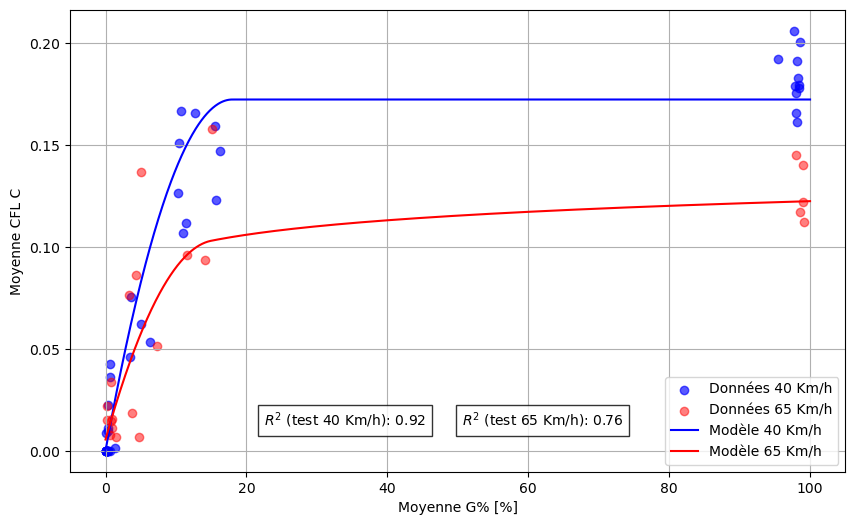

In [57]:
x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v2 = np.where(x <= best_x_k_2,
                     a1_2 + b1_2 * x + c1_2 * (x**2),
                     a2_2 + b2_2 * np.log(x))
y_pred_v1 = np.where(x <= best_x_k,
                     a1 + b1 * x + c1 * (x**2),
                     a2 + b2 * np.log(x))
# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.scatter(slh2['Moyenne G% [%]'], slh2['Moyenne CFL C'], label='Données 40 Km/h', alpha = 0.65, color = "b")
plt.scatter(slh['Moyenne G% [%]'], slh['Moyenne CFL C'], label='Données 65 Km/h', color = "red" ,alpha = 0.5)

plt.plot(x, y_pred_v2, color='b', label='Modèle 40 Km/h')
plt.plot(x, y_pred_v1, color='r', label='Modèle 65 Km/h')



plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
#plt.title(f'Régression par morceaux pour Vitesse_65 = 1')
plt.annotate(f'$R^2$ (test 65 Km/h): {r2_test:.2f}', xy=(0.505, 0.1), xycoords='axes fraction', 
             fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
plt.annotate(f'$R^2$ (test 40 Km/h): {r2_test_2:.2f}', xy=(0.250, 0.1), xycoords='axes fraction', 
             fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
plt.legend()
plt.grid()
plt.show()


In [58]:
max(y_pred_v2)- max(y_pred_v1)


0.049871880951666225

### Comparaison

In [59]:
a1_4=0.005491718931275806
b1_4=0.012319185280966882
c1_4=-0.0003878847645289846
a2_4=0.07527598002760713
b2_4=0.01023963517646813


In [1]:
a1_1=0.038834524881989116
b1_1=0.0211895697036052
c1_1=-0.0009687844342058591
a2_1=0.17310694774154758
b2_1=-0.007643576768650151
c1=11.285714285714286

a1_2=0.03508575425469049
b1_2=0.03899523192012726
c1_2=-0.0018510181313859083
a2_2=0.296451962102173
b2_2=-0.023508231820731366
c2=11.105263157894736

a1_3=4.959170474879524e-14
b1_3=0.012411250316351433
c1_3=-0.00039814354367962655
a2_3=0.1501433283066601
b2_3=-0.01913571286949212
c3=17

a1_4=0.005491718931275806
b1_4=0.012319185280966882
c1_4=-0.0003878847645289846
a2_4=0.07527598002760713
b2_4=0.01023963517646813
c4=15

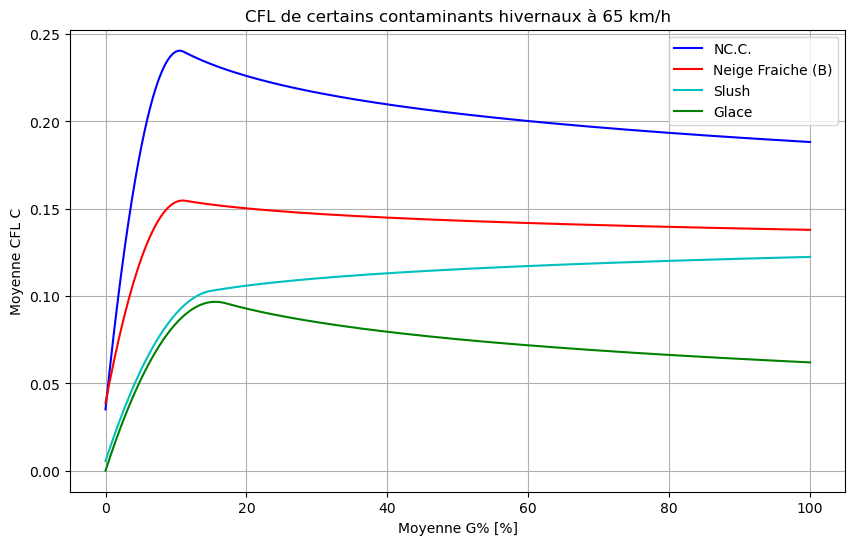

In [4]:
x = np.linspace(0, 100, 1000)
# Calculer les prédictions pour Vitesse_65 = 1
y_pred_v1 = np.where(x <= c1,
                     a1_1 + b1_1 * x + c1_1 * (x**2),
                     a2_1 + b2_1 * np.log(x))
y_pred_v2 = np.where(x <= c2,
                     a1_2 + b1_2 * x + c1_2 * (x**2),
                     a2_2 + b2_2 * np.log(x))
y_pred_v3 = np.where(x <= c3,
                     a1_3 + b1_3 * x + c1_3 * (x**2),
                     a2_3 + b2_3 * np.log(x))
y_pred_v4 = np.where(x <= c4,
                     a1_4 + b1_4 * x + c1_4 * (x**2),
                     a2_4 + b2_4 * np.log(x))


# Tracer les résultats
plt.figure(figsize=(10, 6))
plt.plot(x, y_pred_v2, color='b', label='NC.C.')
plt.plot(x, y_pred_v1, color='red', label='Neige Fraiche (B)')
plt.plot(x, y_pred_v4, color='c', label='Slush')
plt.plot(x, y_pred_v3, color='g', label='Glace')



plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title(f'CFL de certains contaminants hivernaux à 65 km/h')
# plt.ylim(0, 1)

plt.legend()
plt.grid()
plt.show()

### Influence de la vitesse

In [62]:
c = ['Neige fraiche (B)', 'Neige fraiche (G)', 'N.C. (G)', 'N.C. (B)','NC.C.', 'Verglas', 'Glace', 'SLUSH']
D = [0.04, 0.004, 0.04, 0.02, 0.02, 0.01, -0.02, 0.05]

In [63]:
pd.DataFrame({"Contaminant" : c, "Delta(V) = 25 Km/h" : D})

,Contaminant,Delta(V) = 25 Km/h
0,Neige fraiche (B),0.040
1,Neige fraiche (G),0.004
2,N.C. (G),0.040
3,N.C. (B),0.020
4,NC.C.,0.020
5,Verglas,0.010
6,Glace,-0.020
7,SLUSH,0.050
